# GR5243 Project II — Spotify: Content-Based Early Song Promotion Prioritization

**Business problem.** Build a **content-based early promotion prioritization** framework: use **song-level content features** such as audio characteristics, genre information, collaboration structure, duration, and engineered content signals to flag **high-potential** tracks **before** strong market feedback is available. We do **not** claim to fully explain commercial success; we evaluate whether content signals can help **rank** songs for early promotion.

**Starting point:** extends `Stat_5243_Project1.ipynb` using the same Spotify dataset and baseline modeling flow.

**Project I baseline preserved:** same Kaggle/GitHub Spotify dataset, same train/test split (`random_state=42`), **popularity regression**, and **hit classification**. A hit is defined as popularity ≥ the **training-set 75th percentile**, as in Project I.

**Project II main extension:** we focus on a **content-only upgraded framework** using interaction features, genre-relative features, PCA, KMeans clustering, model comparison, and business-oriented top-decile evaluation.

**Supplementary analysis:** artist-level historical aggregate features are computed in a leakage-safe way, but they are treated as a supplementary benchmark rather than the main content-based model because they are derived from the same popularity target within the dataset.

## 1. Setup

Import required libraries, set plotting defaults, and define a single `RANDOM_STATE` for reproducibility across the baseline, content-only upgraded model, and supplementary artist-prior model.

In [ ]:
# 1. SETUP

import warnings
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Setup complete. RANDOM_STATE =", RANDOM_STATE)


Setup complete. RANDOM_STATE = 42


In [ ]:
!pip install vaderSentiment requests -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import requests, time, re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


## 2. Data Loading

Load the Spotify tracks dataset directly from the GitHub raw CSV link used in Project I. This keeps the Project II data source consistent with the original baseline project.

After loading the data, we inspect missing values and duplicate rows, remove the unnecessary index column if present, and drop rows missing core text identifiers such as `artists`, `album_name`, or `track_name`.

In [ ]:
# 2. DATA LOADING

DATA_URL = (
    "https://raw.githubusercontent.com/Boyang6000/spotify-early-song-promotion-prioritization/main/data/dataset.csv"
)

data = pd.read_csv(DATA_URL)

print("Shape:", data.shape)
print("Columns:", list(data.columns))
data.head()


Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Basic inspection
print("Missing values per column:")
print(data.isnull().sum())
print("\nDuplicated rows:", data.duplicated().sum())

if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

data = data.dropna(subset=["artists", "album_name", "track_name"])
data = data.reset_index(drop=True)

print("\nAfter cleanup — shape:", data.shape)
data.describe(include="all").transpose().head(25)


Missing values per column:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Duplicated rows: 0

After cleanup — shape: (113999, 20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,113999,89740,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,113999.0,NaN,NaN,NaN,33.238827,22.304959,0.0,17.0,35.0,50.0,100.0
duration_ms,113999.0,NaN,NaN,NaN,228031.153387,107296.057716,8586.0,174066.0,212906.0,261506.0,5237295.0
explicit,113999,2,False,104252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,113999.0,NaN,NaN,NaN,0.566801,0.173543,0.0,0.456,0.58,0.695,0.985
energy,113999.0,NaN,NaN,NaN,0.641383,0.25153,0.0,0.472,0.685,0.854,1.0
key,113999.0,NaN,NaN,NaN,5.309126,3.559999,0.0,2.0,5.0,8.0,11.0


## 3. Baseline Review

This section preserves the Project I modeling setup as the reference baseline.

**Targets**
- **Regression:** predict `popularity` as a continuous score from 0 to 100.
- **Classification:** define a track as a **hit** if its popularity is greater than or equal to the **75th percentile of the training-set popularity distribution**.

**Features:** We exclude identifiers, text fields, and target variables. The `explicit` column is converted to 0/1, and `track_genre` is one-hot encoded. Ridge and Logistic Regression use standardized features fit on the training set only; tree-based models use the raw tabular features.

**Models:** Ridge, Decision Tree, and Random Forest for regression; Logistic Regression, Decision Tree, and Random Forest for classification.

This baseline is used as the Project I reference model. Later sections compare it against a content-only upgraded model and a supplementary artist-prior model.


In [ ]:
# 3. BASELINE — split + design matrix (Project I logic)

def build_baseline_design_matrix(df):
    """Exclude identifiers/text/targets and one-hot categorical features."""
    exclude_cols = ["track_id", "artists", "album_name", "track_name", "popularity", "is_hit",
                "lfm_listeners", "lfm_playcount", "lfm_top_tag",  # raw (use log versions instead)
                "instrumental_bin"]
    feature_cols = [c for c in df.columns if c not in exclude_cols and c != "instrumental_bin"]

    X = df[feature_cols].copy()
    X["explicit"] = X["explicit"].astype(int)

    categorical_cols = []

    if "track_genre" in X.columns:
        categorical_cols.append("track_genre")

    if "cluster" in X.columns:
        X["cluster"] = X["cluster"].astype(int).astype(str)
        categorical_cols.append("cluster")

    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    return X


n = len(data)
train_idx, test_idx = train_test_split(
    np.arange(n), test_size=0.25, random_state=RANDOM_STATE
)

X_base_full = build_baseline_design_matrix(data)
y_reg = data["popularity"].astype(float)

X_train_base = X_base_full.iloc[train_idx].copy()
X_test_base = X_base_full.iloc[test_idx].copy()
y_train_reg = y_reg.iloc[train_idx].values
y_test_reg = y_reg.iloc[test_idx].values

hit_threshold = float(pd.Series(y_train_reg).quantile(0.75))
y_train_class = (y_train_reg >= hit_threshold).astype(int)
y_test_class = (y_test_reg >= hit_threshold).astype(int)

scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

print(f"Hit threshold (train only): popularity >= {hit_threshold:.2f}")
print("Train hits:", int(y_train_class.sum()), "/", len(y_train_class))
print("Test hits:", int(y_test_class.sum()), "/", len(y_test_class))
print("Baseline feature count:", X_train_base.shape[1])


Hit threshold (train only): popularity >= 50.00
Train hits: 22077 / 85499
Test hits: 7290 / 28500
Baseline feature count: 127


In [ ]:
# 3b. BASELINE MODELS + metric helpers

def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


def clf_metrics(y_true, y_prob, y_pred):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except ValueError:
        out["roc_auc"] = float("nan")
    return out


# Regression baseline
ridge_b = Ridge(alpha=1.0)
dt_b = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10)
rf_b = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

ridge_b.fit(X_train_base_scaled, y_train_reg)
dt_b.fit(X_train_base, y_train_reg)
rf_b.fit(X_train_base, y_train_reg)

baseline_reg_rows = []
for name, model, Xte, scaled in [
    ("Ridge", ridge_b, X_test_base_scaled, True),
    ("Decision Tree", dt_b, X_test_base, False),
    ("Random Forest", rf_b, X_test_base, False),
]:
    m = reg_metrics(y_test_reg, model.predict(Xte))
    m["model"] = name
    m["version"] = "baseline"
    baseline_reg_rows.append(m)

baseline_reg_df = pd.DataFrame(baseline_reg_rows)
print("=== Baseline regression (test) ===")
print(baseline_reg_df.to_string(index=False))

# Classification baseline
lr_b = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight="balanced")
dtc_b = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=12, class_weight="balanced")
rfc_b = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"
)

lr_b.fit(X_train_base_scaled, y_train_class)
dtc_b.fit(X_train_base, y_train_class)
rfc_b.fit(X_train_base, y_train_class)

baseline_clf_rows = []
for name, model, Xte in [
    ("Logistic Regression", lr_b, X_test_base_scaled),
    ("Decision Tree", dtc_b, X_test_base),
    ("Random Forest", rfc_b, X_test_base),
]:
    prob = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)
    m = clf_metrics(y_test_class, prob, pred)
    m["model"] = name
    m["version"] = "baseline"
    baseline_clf_rows.append(m)

baseline_clf_df = pd.DataFrame(baseline_clf_rows)
print("\n=== Baseline classification (test) ===")
print(baseline_clf_df.to_string(index=False))


=== Baseline regression (test) ===
     RMSE       MAE       R2         model  version
19.138325 14.088480 0.262292         Ridge baseline
21.052010 17.198212 0.107385 Decision Tree baseline
15.436618 10.453041 0.520066 Random Forest baseline

=== Baseline classification (test) ===
 accuracy  precision   recall       f1  roc_auc               model  version
 0.704526   0.454118 0.767764 0.570686 0.805817 Logistic Regression baseline
 0.538456   0.325746 0.751852 0.454553 0.662715       Decision Tree baseline
 0.844000   0.790917 0.530316 0.634915 0.895567       Random Forest baseline


### 4. NLP + LASTFM API

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
LASTFM_CACHE_PATH = Path("/content/drive/MyDrive/lastfm_artist_cache.csv")

In [ ]:
print("Current working directory:", os.getcwd())
print("Cache absolute path:", LASTFM_CACHE_PATH.resolve())
print("Cache exists:", LASTFM_CACHE_PATH.exists())

Current working directory: /content
Cache absolute path: /content/drive/MyDrive/lastfm_artist_cache.csv
Cache exists: False


In [ ]:
import os
LASTFM_KEY = os.getenv("LASTFM_API_KEY")

if not LASTFM_KEY:
    raise ValueError("Set LASTFM_API_KEY before running the Last.fm API collection cell.")

ALLOW_LASTFM_API_CALL = True
SAVE_EVERY = 100

def normalize_primary_artist(artist_value):
    if pd.isna(artist_value):
        return np.nan
    primary = str(artist_value).split(";")[0].strip()
    return primary if primary else np.nan

data["primary_artist"] = data["artists"].apply(normalize_primary_artist)

unique_primary_artists = (
    data["primary_artist"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"Unique primary artists: {len(unique_primary_artists):,}")
print(f"Cache path: {LASTFM_CACHE_PATH.resolve()}")
print(f"Cache exists before run: {LASTFM_CACHE_PATH.exists()}")

def get_artist_lastfm(artist_name, api_key):
    url = "https://ws.audioscrobbler.com/2.0/"
    params = {
        "method": "artist.getInfo",
        "artist": artist_name,
        "api_key": api_key,
        "format": "json",
        "autocorrect": 1,
    }

    result = {
        "primary_artist": artist_name,
        "lfm_artist_name": np.nan,
        "lfm_listeners": 0,
        "lfm_playcount": 0,
        "lfm_top_tag": "unknown",
        "lfm_api_status": "not_matched",
    }

    try:
        r = requests.get(url, params=params, timeout=8)

        if r.status_code != 200:
            result["lfm_api_status"] = f"http_{r.status_code}"
            return result

        d = r.json()

        if "artist" not in d:
            result["lfm_api_status"] = "not_found"
            return result

        artist = d["artist"]
        stats = artist.get("stats", {})
        tags = artist.get("tags", {}).get("tag", [])

        try:
            listeners = int(stats.get("listeners", 0))
        except Exception:
            listeners = 0

        try:
            playcount = int(stats.get("playcount", 0))
        except Exception:
            playcount = 0

        top_tag = "unknown"
        if isinstance(tags, list) and len(tags) > 0:
            top_tag = str(tags[0].get("name", "unknown")).lower()

        result.update({
            "lfm_artist_name": artist.get("name", artist_name),
            "lfm_listeners": listeners,
            "lfm_playcount": playcount,
            "lfm_top_tag": top_tag,
            "lfm_api_status": "matched" if listeners > 0 or playcount > 0 else "empty_stats",
        })

    except Exception as e:
        result["lfm_api_status"] = f"error_{type(e).__name__}"

    return result


# Load existing partial or completed cache
if LASTFM_CACHE_PATH.exists():
    df_lfm_existing = pd.read_csv(LASTFM_CACHE_PATH)
    print(f"Loaded existing cache: {df_lfm_existing.shape}")

    if "primary_artist" not in df_lfm_existing.columns:
        raise ValueError("Existing cache does not have primary_artist column.")

    cached_artists = set(df_lfm_existing["primary_artist"].dropna().astype(str))
    artist_results = df_lfm_existing.to_dict("records")
else:
    df_lfm_existing = pd.DataFrame()
    cached_artists = set()
    artist_results = []

artists_to_query = [
    artist for artist in unique_primary_artists
    if artist not in cached_artists
]

print(f"Already cached artists: {len(cached_artists):,}")
print(f"Remaining artists to query: {len(artists_to_query):,}")

if len(artists_to_query) > 0 and not ALLOW_LASTFM_API_CALL:
    raise FileNotFoundError(
        "Cache is incomplete and ALLOW_LASTFM_API_CALL is False. "
        "Set it to True only when you intentionally want to continue querying Last.fm."
    )

for i, artist in enumerate(artists_to_query):
    artist_results.append(get_artist_lastfm(artist, LASTFM_KEY))
    time.sleep(0.3)

    if (i + 1) % SAVE_EVERY == 0 or (i + 1) == len(artists_to_query):
        df_checkpoint = pd.DataFrame(artist_results)
        df_checkpoint = df_checkpoint.drop_duplicates(subset=["primary_artist"], keep="last")
        df_checkpoint.to_csv(LASTFM_CACHE_PATH, index=False)

        print(
            f"Saved checkpoint: {len(df_checkpoint):,}/{len(unique_primary_artists):,} artists "
            f"to {LASTFM_CACHE_PATH}"
        )

df_lfm = pd.read_csv(LASTFM_CACHE_PATH)

# Create derived features from cached raw columns
df_lfm["lfm_listeners"] = pd.to_numeric(df_lfm["lfm_listeners"], errors="coerce").fillna(0)
df_lfm["lfm_playcount"] = pd.to_numeric(df_lfm["lfm_playcount"], errors="coerce").fillna(0)

df_lfm["lfm_matched"] = (
    (df_lfm["lfm_listeners"] > 0) |
    (df_lfm["lfm_playcount"] > 0)
).astype(int)

df_lfm["lfm_listeners_log"] = np.log1p(df_lfm["lfm_listeners"])
df_lfm["lfm_playcount_log"] = np.log1p(df_lfm["lfm_playcount"])

df_lfm["lfm_play_per_listener"] = (
    df_lfm["lfm_playcount"] / df_lfm["lfm_listeners"].replace(0, np.nan)
)

df_lfm["lfm_play_per_listener_log"] = np.log1p(
    df_lfm["lfm_play_per_listener"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df_lfm.to_csv(LASTFM_CACHE_PATH, index=False)

print("\nLast.fm cache ready.")
print(f"Final cache path: {LASTFM_CACHE_PATH.resolve()}")
print(f"Final cache shape: {df_lfm.shape}")
print(f"Artist-level match rate: {df_lfm['lfm_matched'].mean():.2%}")

display(df_lfm.head(10))

Unique primary artists: 17,648
Cache path: /content/drive/MyDrive/lastfm_artist_cache.csv
Cache exists before run: False
Already cached artists: 0
Remaining artists to query: 17,648
Saved checkpoint: 100/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 200/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 300/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 400/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 500/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 600/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 700/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 800/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 900/17,648 artists to /content/drive/MyDrive/lastfm_artist_cache.csv
Saved checkpoint: 1,000/17,648 arti

,primary_artist,lfm_artist_name,lfm_listeners,lfm_playcount,lfm_top_tag,lfm_api_status,lfm_matched,lfm_listeners_log,lfm_playcount_log,lfm_play_per_listener,lfm_play_per_listener_log
0,!nvite,!nvite,9622,24795,unknown,matched,1,9.171911,10.118438,2.576907,1.274498
1,"""Puppy Dog Pals"" Cast","""Puppy Dog Pals"" Cast",19723,195735,unknown,matched,1,9.889591,12.184522,9.924200,2.390981
2,"""Weird Al"" Yankovic","""Weird Al"" Yankovic",980212,26673103,comedy,matched,1,13.795525,17.099166,27.211565,3.339732
3,#Kids,#Kids,885,5063,unknown,matched,1,6.786717,8.529912,5.720904,1.905223
4,$affie,$affie,13090,35138,unknown,matched,1,9.479680,10.467067,2.684339,1.304091
5,&ME,&ME,182596,1782024,minimal,matched,1,12.115037,14.393261,9.759381,2.375778
6,'Falsettos' 2016 Broadway Company,'Falsettos' 2016 Broadway Company,30164,730881,unknown,matched,1,10.314438,13.502007,24.230241,3.228043
7,'Til Tuesday,'Til Tuesday,250935,2045034,new wave,matched,1,12.432953,14.530925,8.149656,2.213716
8,(DOLCH),(DOLCH),39953,474429,doom metal,matched,1,10.595484,13.069869,11.874678,2.555262
9,(G)I-DLE,(G)I-DLE,955093,104188142,k-pop,matched,1,13.769565,18.461709,109.086908,4.701270


In [ ]:
# NLP FEATURES FROM TRACK NAME
# No external data needed — uses existing track_name column

import re
import numpy as np
import pandas as pd

# VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

NLP_COLS = [
    "title_sentiment",
    "title_word_count",
    "title_char_len",
    "title_has_feat",
    "title_has_remix",
    "title_is_short",
    "title_has_love",
    "title_has_number",
    "title_exclamation",
]

def extract_title_nlp(name):
    if not isinstance(name, str):
        return {k: 0 for k in NLP_COLS}

    name_lower = name.lower()
    s = analyzer.polarity_scores(name)
    words = re.findall(r"[a-zA-Z]+", name_lower)

    return {
        "title_sentiment":   s["compound"],
        "title_word_count":  len(words),
        "title_char_len":    len(name),
        "title_has_feat":    int(bool(re.search(r"\bfeat\b|\bft\b|\bfeaturing\b|\bwith\b|;|&", name_lower))),
        "title_has_remix":   int(bool(re.search(r"\bremix\b|\bmix\b|\bedit\b|\bversion\b", name_lower))),
        "title_is_short":    int(len(words) <= 2),
        "title_has_love":    int("love" in name_lower),
        "title_has_number":  int(bool(re.search(r"\d", name))),
        "title_exclamation": int("!" in name),
    }

# Drop old NLP columns first so rerunning this cell is safe.
data = data.drop(columns=[c for c in NLP_COLS if c in data.columns], errors="ignore")

nlp_feats = data["track_name"].apply(extract_title_nlp)
nlp_df = pd.DataFrame(nlp_feats.tolist(), index=data.index)

data = pd.concat([data, nlp_df], axis=1)

print(f"NLP features added: {NLP_COLS}")
display(data[NLP_COLS].describe().round(3))
display(data[["track_name"] + NLP_COLS].head(10))

NLP features added: ['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation']


,title_sentiment,title_word_count,title_char_len,title_has_feat,title_has_remix,title_is_short,title_has_love,title_has_number,title_exclamation
count,113999.000,113999.000,113999.000,113999.000,113999.000,113999.000,113999.000,113999.000,113999.000
mean,0.026,3.244,17.995,0.043,0.064,0.446,0.025,0.060,0.007
std,0.224,2.375,13.148,0.203,0.244,0.497,0.155,0.237,0.085
min,-0.935,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,2.000,9.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,3.000,15.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,4.000,23.000,0.000,0.000,1.000,0.000,0.000,0.000
max,0.935,75.000,511.000,1.000,1.000,1.000,1.000,1.000,1.000


,track_name,title_sentiment,title_word_count,title_char_len,title_has_feat,title_has_remix,title_is_short,title_has_love,title_has_number,title_exclamation
0,Comedy,0.3612,1,6,0,0,1,0,0,0
1,Ghost - Acoustic,-0.3182,2,16,0,0,1,0,0,0
2,To Begin Again,0.0000,3,14,0,0,0,0,0,0
3,Can't Help Falling In Love,0.5245,6,26,0,0,0,1,0,0
4,Hold On,0.0000,2,7,0,0,1,0,0,0
5,Days I Will Remember,0.0000,4,20,0,0,0,0,0,0
6,Say Something,0.0000,2,13,0,0,1,0,0,0
7,I'm Yours,0.0000,3,9,0,0,0,0,0,0
8,Lucky,0.4215,1,5,0,0,1,0,0,0
9,Hunger,-0.2500,1,6,0,0,1,0,0,0


### Last.fm Cached Artist Features Merge

This section loads the completed Last.fm artist cache from Google Drive and merges it into the main `data` dataframe using `primary_artist`.

The goal is to add external artist-level popularity features, including listener count, playcount, match indicator, and play-per-listener ratio, without calling the Last.fm API again.

This section must run before `df = data.copy()` so that the Last.fm features are included in downstream feature engineering, the design matrix, and model comparison.

In [ ]:
print(f"Loaded Last.fm cache from: {LASTFM_CACHE_PATH}")
print("Last.fm cache shape:", df_lfm.shape)
print("Last.fm cache columns:", df_lfm.columns.tolist())


def normalize_primary_artist(artist_value):
    """
    Use only the first artist from strings like:
    'Artist1;Artist2' -> 'Artist1'
    """
    if pd.isna(artist_value):
        return np.nan

    primary = str(artist_value).split(";")[0].strip()
    return primary if primary else np.nan


# Create the same merge key used in the Last.fm cache.
data["primary_artist"] = data["artists"].apply(normalize_primary_artist)

# Make sure required raw columns exist.
required_lfm_cols = {
    "primary_artist": np.nan,
    "lfm_artist_name": "unknown",
    "lfm_listeners": 0,
    "lfm_playcount": 0,
    "lfm_top_tag": "unknown",
    "lfm_api_status": "unknown",
}

for col, default_value in required_lfm_cols.items():
    if col not in df_lfm.columns:
        df_lfm[col] = default_value

# Clean numeric raw columns.
df_lfm["lfm_listeners"] = pd.to_numeric(
    df_lfm["lfm_listeners"], errors="coerce"
).fillna(0)

df_lfm["lfm_playcount"] = pd.to_numeric(
    df_lfm["lfm_playcount"], errors="coerce"
).fillna(0)

# Recreate derived features if needed.
# This is safe and does not call the API.
df_lfm["lfm_matched"] = (
    (df_lfm["lfm_listeners"] > 0) |
    (df_lfm["lfm_playcount"] > 0)
).astype(int)

df_lfm["lfm_listeners_log"] = np.log1p(df_lfm["lfm_listeners"])
df_lfm["lfm_playcount_log"] = np.log1p(df_lfm["lfm_playcount"])

df_lfm["lfm_play_per_listener"] = (
    df_lfm["lfm_playcount"] / df_lfm["lfm_listeners"].replace(0, np.nan)
)

df_lfm["lfm_play_per_listener_log"] = np.log1p(
    df_lfm["lfm_play_per_listener"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Save enriched cache back to Drive.
# This does not call Last.fm; it only ensures the cache has all derived columns.
df_lfm.to_csv(LASTFM_CACHE_PATH, index=False)

lfm_merge_cols = [
    "primary_artist",
    "lfm_artist_name",
    "lfm_listeners",
    "lfm_playcount",
    "lfm_top_tag",
    "lfm_api_status",
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener",
    "lfm_play_per_listener_log",
]

# Drop existing Last.fm columns before merge so rerunning this cell is safe.
old_lfm_cols = [
    c for c in lfm_merge_cols
    if c != "primary_artist" and c in data.columns
]

data = data.drop(columns=old_lfm_cols, errors="ignore")

# Merge Last.fm features into the main dataset.
data = data.merge(
    df_lfm[lfm_merge_cols].drop_duplicates(subset=["primary_artist"]),
    on="primary_artist",
    how="left"
)

# Fill missing values after merge.
numeric_lfm_cols = [
    "lfm_listeners",
    "lfm_playcount",
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener",
    "lfm_play_per_listener_log",
]

for col in numeric_lfm_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce").fillna(0)

data["lfm_artist_name"] = data["lfm_artist_name"].fillna("unknown")
data["lfm_top_tag"] = data["lfm_top_tag"].fillna("unknown")
data["lfm_api_status"] = data["lfm_api_status"].fillna("missing_after_merge")

LFM_COLS = [
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

print("\nLast.fm features merged into data.")
print(f"Track-level Last.fm match rate: {data['lfm_matched'].mean():.2%}")
print("Last.fm model columns:", LFM_COLS)

display(data[
    [
        "artists",
        "primary_artist",
        "lfm_artist_name",
        "lfm_matched",
        "lfm_listeners_log",
        "lfm_playcount_log",
        "lfm_play_per_listener_log",
        "popularity",
    ]
].head(10))

Loaded Last.fm cache from: /content/drive/MyDrive/lastfm_artist_cache.csv
Last.fm cache shape: (17648, 11)
Last.fm cache columns: ['primary_artist', 'lfm_artist_name', 'lfm_listeners', 'lfm_playcount', 'lfm_top_tag', 'lfm_api_status', 'lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log', 'lfm_play_per_listener', 'lfm_play_per_listener_log']

Last.fm features merged into data.
Track-level Last.fm match rate: 99.98%
Last.fm model columns: ['lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log', 'lfm_play_per_listener_log']


,artists,primary_artist,lfm_artist_name,lfm_matched,lfm_listeners_log,lfm_playcount_log,lfm_play_per_listener_log,popularity
0,Gen Hoshino,Gen Hoshino,Gen Hoshino,1,12.409748,15.313516,2.957138,73
1,Ben Woodward,Ben Woodward,Ben Woodward,1,10.749699,12.638994,2.030097,55
2,Ingrid Michaelson;ZAYN,Ingrid Michaelson,Ingrid Michaelson,1,14.203310,17.309986,3.150454,57
3,Kina Grannis,Kina Grannis,Kina Grannis,1,13.252902,15.753228,2.579193,71
4,Chord Overstreet,Chord Overstreet,Chord Overstreet,1,12.946881,15.314599,2.457281,82
5,Tyrone Wells,Tyrone Wells,Tyrone Wells,1,12.491654,14.846422,2.445449,58
6,A Great Big World;Christina Aguilera,A Great Big World,A Great Big World,1,13.641983,15.949997,2.402833,74
7,Jason Mraz,Jason Mraz,Jason Mraz,1,15.061393,18.388145,3.362033,80
8,Jason Mraz;Colbie Caillat,Jason Mraz,Jason Mraz,1,15.061393,18.388145,3.362033,74
9,Ross Copperman,Ross Copperman,Ross Copperman,1,12.021055,14.168001,2.257454,56


## 5. Feature Engineering

This section creates two groups of engineered features: content-based features for the main upgraded model, and artist-prior features for the supplementary benchmark.

**Content features:** We created `num_artists`, `is_collab`, `duration_min`, `duration_log`, duration tertile buckets, and interaction terms including `energy_loudness`, `danceability_energy`, and `valence_energy`. Duration bucket cutoffs were computed from the training set only.

**Genre-relative features:** For `energy`, `danceability`, and `valence`, we subtracted the corresponding training-set genre mean. These features measure whether a song is higher or lower than its genre average on selected audio dimensions.

**Artist-prior features for supplementary analysis:** We also computed `artist_song_count`, `artist_avg_popularity`, and `artist_hit_rate` after the train/test split. These features are not used in the main content-only model. They are included only in a supplementary artist-prior model because they are derived from the same popularity target within the dataset.

**Leakage control:** For artist-prior features, training rows use leave-one-out aggregation so each track's own popularity or hit label is excluded. Test rows use artist statistics computed from the training set only. For cold-start artists, `artist_song_count` is set to 0, while `artist_avg_popularity` and `artist_hit_rate` are filled with global training averages.

In [ ]:
# ── SECTION 5: FEATURE ENGINEERING USING UPDATED DATA ───────────────────────

# Check that NLP and Last.fm features already exist before creating df.
expected_pre_engineering_cols = [
    # NLP features
    "title_sentiment",
    "title_word_count",
    "title_char_len",
    "title_has_feat",
    "title_has_remix",
    "title_is_short",
    "title_has_love",
    "title_has_number",
    "title_exclamation",

    # Last.fm features
    "primary_artist",
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

missing_pre_engineering_cols = [
    c for c in expected_pre_engineering_cols
    if c not in data.columns
]

if missing_pre_engineering_cols:
    print("WARNING: These expected NLP / Last.fm columns are missing from data:")
    print(missing_pre_engineering_cols)
else:
    print("All expected NLP and Last.fm columns are present in data.")

# Create modeling dataframe after NLP and Last.fm merge.
df = data.copy()

print("Modeling dataframe created.")
print("df shape:", df.shape)

# Keep train/test row indices from the existing split
train_ids = df.index[train_idx]
test_ids = df.index[test_idx]

# Create primary artist and collaboration features
# primary_artist should already exist from the Last.fm merge.
# This fallback keeps the cell safe if rerun independently.
df["artists"] = df["artists"].astype(str)
artist_parts = df["artists"].str.split(";")

if "primary_artist" not in df.columns:
    df["primary_artist"] = artist_parts.str[0].astype(str).str.strip()
else:
    df["primary_artist"] = df["primary_artist"].fillna(
        artist_parts.str[0].astype(str).str.strip()
    )

df["num_artists"] = artist_parts.apply(
    lambda x: len([a.strip() for a in x if isinstance(a, str) and a.strip() != ""])
)

df["num_artists"] = df["num_artists"].replace(0, 1)
df["is_collab"] = (df["num_artists"] > 1).astype(int)

# Create duration features
df["duration_min"] = df["duration_ms"] / 60000.0
df["duration_log"] = np.log1p(df["duration_ms"].astype(float))

# Use train-set cutoffs for duration buckets
q1, q2 = df.loc[train_ids, "duration_min"].quantile([1 / 3, 2 / 3]).values

df["duration_bucket"] = np.where(
    df["duration_min"] <= q1,
    "short",
    np.where(df["duration_min"] <= q2, "medium", "long")
)

# Create interaction features
df["energy_loudness"] = df["energy"] * df["loudness"]
df["danceability_energy"] = df["danceability"] * df["energy"]
df["valence_energy"] = df["valence"] * df["energy"]

# Create genre-relative features using train-set genre means
gcols = ["energy", "danceability", "valence"]
genre_mean_cols = []

for c in gcols:
    genre_mean_map = df.loc[train_ids].groupby("track_genre")[c].mean()
    global_feature_mean = df.loc[train_ids, c].mean()

    mean_col = f"{c}_genre_train_mean"
    rel_col = f"{c}_minus_genre_mean"

    df[mean_col] = df["track_genre"].map(genre_mean_map).fillna(global_feature_mean)
    df[rel_col] = df[c] - df[mean_col]

    genre_mean_cols.append(mean_col)

# Create train-only hit label for artist-level aggregation
df["_hit_tr"] = np.nan
df.loc[train_ids, "_hit_tr"] = (
    df.loc[train_ids, "popularity"] >= hit_threshold
).astype(int)

# Use only training data to compute artist statistics
train_artist = df.loc[
    train_ids,
    ["primary_artist", "popularity", "_hit_tr"]
].copy()

artist_stats = train_artist.groupby("primary_artist").agg(
    artist_train_count=("popularity", "size"),
    artist_pop_sum=("popularity", "sum"),
    artist_hit_sum=("_hit_tr", "sum")
)

global_avg_pop = float(train_artist["popularity"].mean())
global_hit_rate = float(train_artist["_hit_tr"].mean())

# Initialize artist-level features
df["artist_song_count"] = np.nan
df["artist_avg_popularity"] = np.nan
df["artist_hit_rate"] = np.nan

# Use leave-one-out artist statistics for training rows
train_tmp = train_artist.join(artist_stats, on="primary_artist")

loo_count = train_tmp["artist_train_count"] - 1
loo_pop_sum = train_tmp["artist_pop_sum"] - train_tmp["popularity"]
loo_hit_sum = train_tmp["artist_hit_sum"] - train_tmp["_hit_tr"]

loo_avg_pop = pd.Series(global_avg_pop, index=train_tmp.index)
loo_hit_rate = pd.Series(global_hit_rate, index=train_tmp.index)

has_history = loo_count > 0

loo_avg_pop.loc[has_history] = (
    loo_pop_sum.loc[has_history] / loo_count.loc[has_history]
)

loo_hit_rate.loc[has_history] = (
    loo_hit_sum.loc[has_history] / loo_count.loc[has_history]
)

df.loc[train_ids, "artist_song_count"] = loo_count.values
df.loc[train_ids, "artist_avg_popularity"] = loo_avg_pop.values
df.loc[train_ids, "artist_hit_rate"] = loo_hit_rate.values

# Use train-set artist statistics for test rows
artist_count_map = artist_stats["artist_train_count"]
artist_avg_map = artist_stats["artist_pop_sum"] / artist_stats["artist_train_count"]
artist_hit_map = artist_stats["artist_hit_sum"] / artist_stats["artist_train_count"]

df.loc[test_ids, "artist_song_count"] = (
    df.loc[test_ids, "primary_artist"]
    .map(artist_count_map)
    .fillna(0)
    .values
)

df.loc[test_ids, "artist_avg_popularity"] = (
    df.loc[test_ids, "primary_artist"]
    .map(artist_avg_map)
    .fillna(global_avg_pop)
    .values
)

df.loc[test_ids, "artist_hit_rate"] = (
    df.loc[test_ids, "primary_artist"]
    .map(artist_hit_map)
    .fillna(global_hit_rate)
    .values
)

# Convert duration bucket into dummy variables
df = pd.get_dummies(df, columns=["duration_bucket"], drop_first=True)

# Drop helper genre mean columns and temporary hit label.
# Keep primary_artist for audit/debugging; the design matrix function will exclude it from modeling.
drop_tmp = genre_mean_cols + ["_hit_tr"]
df = df.drop(columns=[c for c in drop_tmp if c in df.columns])

# Refresh train and test dataframes
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

# Preview engineered features
eng_cols = [
    "num_artists",
    "is_collab",
    "duration_min",
    "duration_log",
    "energy_loudness",
    "danceability_energy",
    "valence_energy",
    "energy_minus_genre_mean",
    "danceability_minus_genre_mean",
    "valence_minus_genre_mean",
    "artist_song_count",
    "artist_avg_popularity",
    "artist_hit_rate",
]

new_feature_cols = [
    c for c in df.columns
    if c.startswith("title_") or c.startswith("lfm_")
]

print("Feature engineering complete.")
print("\nMissing values in engineered features:")
print(df[eng_cols].isnull().sum())

print("\nNLP and Last.fm columns retained in df:")
print(new_feature_cols)

print("\nSample engineered features:")
display(train_df[eng_cols].head())

All expected NLP and Last.fm columns are present in data.
Modeling dataframe created.
df shape: (113999, 40)
Feature engineering complete.

Missing values in engineered features:
num_artists                      0
is_collab                        0
duration_min                     0
duration_log                     0
energy_loudness                  0
danceability_energy              0
valence_energy                   0
energy_minus_genre_mean          0
danceability_minus_genre_mean    0
valence_minus_genre_mean         0
artist_song_count                0
artist_avg_popularity            0
artist_hit_rate                  0
dtype: int64

NLP and Last.fm columns retained in df:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation', 'lfm_artist_name', 'lfm_listeners', 'lfm_playcount', 'lfm_top_tag', 'lfm_api_status', 'lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log

,num_artists,is_collab,duration_min,duration_log,energy_loudness,danceability_energy,valence_energy,energy_minus_genre_mean,danceability_minus_genre_mean,valence_minus_genre_mean,artist_song_count,artist_avg_popularity,artist_hit_rate
96697,2,1,3.533767,12.264469,-6.571476,0.381696,0.481380,0.183561,-0.127977,-0.127835,0.0,33.291886,0.258214
53743,3,1,2.509333,11.922124,-3.109038,0.531474,0.762402,0.095201,-0.040534,0.403477,15.0,15.933333,0.200000
103084,1,0,2.821550,12.039392,-3.237440,0.174200,0.116848,0.001428,-0.276948,-0.306063,183.0,0.939891,0.010929
8838,1,0,4.803550,12.571459,-3.160324,0.462428,0.473809,0.013096,0.204803,0.188549,4.0,35.250000,0.000000
113094,1,0,6.819100,12.921830,-3.804464,0.222088,0.073272,0.031676,-0.022439,-0.120858,128.0,44.570312,0.195312


In [ ]:
# ── CHECK: DID NLP AND LAST.FM FEATURES ENTER THE MODEL MATRIX? ──────────────
X_all_full = build_baseline_design_matrix(df)

drop_from_model = [
    "lfm_artist_name",
    "lfm_api_status",
    "lfm_play_per_listener",
]

X_all_full = X_all_full.drop(columns=drop_from_model, errors="ignore")

new_cols_in_df = [
    c for c in df.columns
    if c.startswith("title_") or c.startswith("lfm_")
]

new_cols_in_model = [
    c for c in X_all_full.columns
    if c.startswith("title_") or c.startswith("lfm_")
]

print("NLP / Last.fm columns in df:")
print(new_cols_in_df)

print("\nNLP / Last.fm columns in X_all_full:")
print(new_cols_in_model)

print("\nNumber of NLP / Last.fm columns in df:", len(new_cols_in_df))
print("Number of NLP / Last.fm columns in X_all_full:", len(new_cols_in_model))

expected_model_cols = [
    "title_sentiment",
    "title_word_count",
    "title_char_len",
    "title_has_feat",
    "title_has_remix",
    "title_is_short",
    "title_has_love",
    "title_has_number",
    "title_exclamation",
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

missing_from_df = [c for c in expected_model_cols if c not in df.columns]
missing_from_model = [c for c in expected_model_cols if c not in X_all_full.columns]

print("\nMissing expected columns from df:")
print(missing_from_df)

print("\nMissing expected columns from X_all_full:")
print(missing_from_model)

if len(missing_from_model) == 0:
    print("\nSUCCESS: All expected NLP and Last.fm features are included in X_all_full.")
else:
    print("\nWARNING: Some expected NLP / Last.fm features are missing from X_all_full.")

NLP / Last.fm columns in df:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation', 'lfm_artist_name', 'lfm_listeners', 'lfm_playcount', 'lfm_top_tag', 'lfm_api_status', 'lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log', 'lfm_play_per_listener', 'lfm_play_per_listener_log']

NLP / Last.fm columns in X_all_full:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation', 'lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log', 'lfm_play_per_listener_log']

Number of NLP / Last.fm columns in df: 19
Number of NLP / Last.fm columns in X_all_full: 13

Missing expected columns from df:
[]

Missing expected columns from X_all_full:
[]

SUCCESS: All expected NLP and Last.fm features are included in X_all_full.


## 6. PCA

We apply PCA to the standardized continuous audio features to summarize the main low-dimensional structure of song content.

The scaler and PCA model are fit on the training set only, then applied to the test set. We store `PC1` and `PC2` as compact audio representations and use the PC1–PC2 scatter plot to visualize whether hit and non-hit songs show any separation in the audio-feature space.

PCA is mainly used for visualization and content representation, not as evidence that audio features alone fully explain popularity.


Explained variance ratio (first components):
  PC1: 31.97%
  PC2: 15.80%
  PC3: 13.53%
  PC4: 10.15%
  PC5: 9.82%
  PC6: 8.36%
  PC7: 5.21%
  PC8: 3.59%
  PC9: 1.55%
Cumulative PC1+PC2: 47.78%


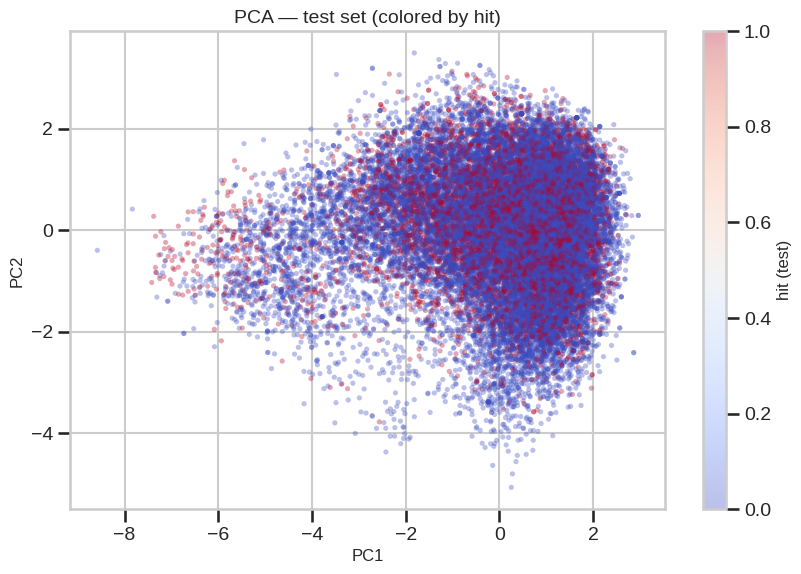

In [ ]:
# 6. PCA

AUDIO_COLS = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

pca_scaler = StandardScaler()
Z_train = pca_scaler.fit_transform(train_df[AUDIO_COLS])
Z_test = pca_scaler.transform(test_df[AUDIO_COLS])

pca = PCA(n_components=min(10, len(AUDIO_COLS)), random_state=RANDOM_STATE)
pca.fit(Z_train)
train_pc = pca.transform(Z_train)
test_pc = pca.transform(Z_test)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["PC1"] = train_pc[:, 0]
train_df["PC2"] = train_pc[:, 1]
test_df["PC1"] = test_pc[:, 0]
test_df["PC2"] = test_pc[:, 1]

df["PC1"] = np.nan
df["PC2"] = np.nan
df.loc[train_df.index, "PC1"] = train_df["PC1"].values
df.loc[train_df.index, "PC2"] = train_df["PC2"].values
df.loc[test_df.index, "PC1"] = test_df["PC1"].values
df.loc[test_df.index, "PC2"] = test_df["PC2"].values

evr = pca.explained_variance_ratio_
print("Explained variance ratio (first components):")
for i, r in enumerate(evr, 1):
    print(f"  PC{i}: {100*r:.2f}%")
print(f"Cumulative PC1+PC2: {100*(evr[0]+evr[1]):.2f}%")

fig, ax = plt.subplots(figsize=(8.5, 6))
sc = ax.scatter(
    test_df["PC1"],
    test_df["PC2"],
    c=y_test_class,
    cmap="coolwarm",
    alpha=0.35,
    s=14,
    edgecolors="none",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — test set (colored by hit)")
plt.colorbar(sc, ax=ax, label="hit (test)")
plt.tight_layout()
plt.show()


## 7. Clustering

We use KMeans clustering on the standardized audio features to create interpretable song archetypes. The goal is not to prove that clusters perfectly predict popularity, but to support content-based segmentation and business interpretation.

We evaluate `k` from 2 to 10 using inertia and silhouette score. Although the silhouette-best value may favor fewer clusters, we use at least 3 clusters when needed for interpretability, so the clusters can be translated into practical music profiles.


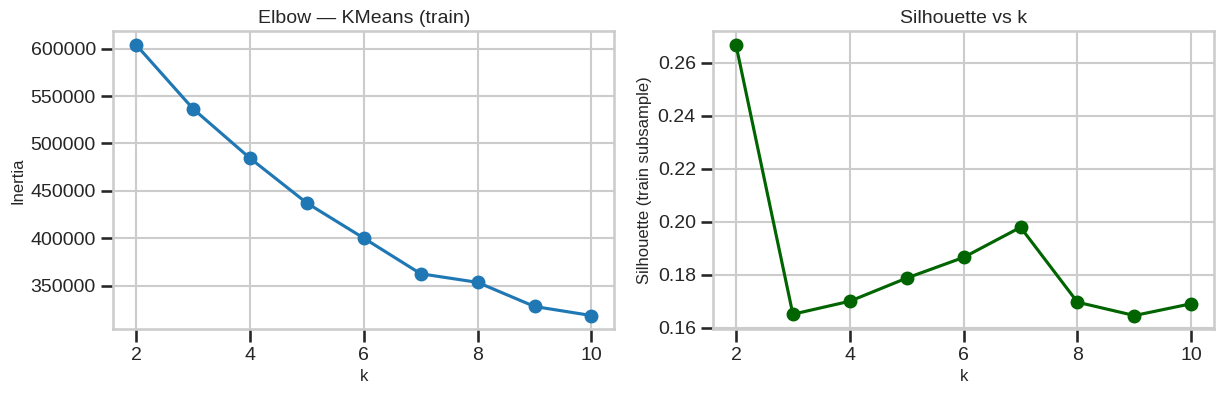

Silhouette-best k = 2; CHOSEN_K used in models = 3


,cluster,n,mean_danceability,mean_energy,mean_loudness,mean_speechiness,mean_acousticness,mean_instrumentalness,mean_liveness,mean_valence,mean_tempo,mean_popularity,hit_rate,cluster_name
0,0,38757,0.480340,0.806968,-5.965985,0.081810,0.087794,0.191020,0.263058,0.341881,135.785864,34.361896,0.257786,mid-profile blend
1,1,50893,0.685823,0.687460,-6.927430,0.101703,0.272417,0.050538,0.194861,0.662516,117.692897,33.307469,0.264752,upbeat mainstream
2,2,24349,0.455648,0.281509,-14.691800,0.053538,0.765218,0.320928,0.173829,0.290579,109.750615,31.307733,0.242392,acoustic emotional


In [ ]:
# 7. CLUSTERING

K_RANGE = list(range(2, 11))
inertias = []
sil_scores = []
rng = np.random.RandomState(RANDOM_STATE)
sub_n = min(8000, Z_train.shape[0])
sub_idx = rng.choice(Z_train.shape[0], size=sub_n, replace=False)
Z_sub = Z_train[sub_idx]

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(Z_train)
    inertias.append(km.inertia_)
    km_sub = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    lab_sub = km_sub.fit_predict(Z_sub)
    sil_scores.append(silhouette_score(Z_sub, lab_sub))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(K_RANGE, inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow — KMeans (train)")

axes[1].plot(K_RANGE, sil_scores, marker="o", color="darkgreen")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette (train subsample)")
axes[1].set_title("Silhouette vs k")
plt.tight_layout()
plt.show()

best_k = K_RANGE[int(np.argmax(sil_scores))]
CHOSEN_K = max(3, best_k)
print(f"Silhouette-best k = {best_k}; CHOSEN_K used in models = {CHOSEN_K}")

kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init="auto")
train_df["cluster"] = kmeans_final.fit_predict(Z_train)
test_df["cluster"] = kmeans_final.predict(Z_test)

df["cluster"] = np.nan
df.loc[train_df.index, "cluster"] = train_df["cluster"].values
df.loc[test_df.index, "cluster"] = test_df["cluster"].values

summary_list = []
for c in range(CHOSEN_K):
    sub = df[df["cluster"] == c]
    row = {"cluster": int(c), "n": len(sub)}
    for ac in AUDIO_COLS:
        row[f"mean_{ac}"] = sub[ac].mean()
    row["mean_popularity"] = sub["popularity"].mean()
    row["hit_rate"] = (sub["popularity"] >= hit_threshold).mean()
    summary_list.append(row)

cluster_summary = pd.DataFrame(summary_list).sort_values("mean_popularity", ascending=False)
overall = df[AUDIO_COLS + ["popularity"]].mean()


def name_cluster(row):
    e = row["mean_energy"]
    d = row["mean_danceability"]
    v = row["mean_valence"]
    a = row["mean_acousticness"]
    mp = row["mean_popularity"]
    if e > overall["energy"] and d > overall["danceability"] and v > overall["valence"]:
        return "upbeat mainstream"
    if a > overall["acousticness"] and e < overall["energy"]:
        return "acoustic emotional"
    if e < overall["energy"] and mp < overall["popularity"]:
        return "low-energy niche"
    if d > overall["danceability"] and e > overall["energy"]:
        return "dance-forward energetic"
    return "mid-profile blend"


cluster_summary["cluster_name"] = cluster_summary.apply(name_cluster, axis=1)
cluster_summary


## 7. Content-Only Upgraded Models

This is the main Project II upgraded model. It uses the original baseline features plus engineered content features, PCA components, and cluster labels.

Artist-prior features are excluded from this main model because they are derived from the same popularity target within the dataset. This allows us to evaluate whether music/content signals alone provide useful predictive and ranking value.

### Content + NLP Upgraded Models

This section trains upgraded content-based models using Spotify audio features, engineered content features, PCA features, cluster features, genre features, duration features, and title-level NLP features.

The goal is to evaluate the predictive power of track-level content and title information without using external artist popularity signals or internal artist-prior features.

Last.fm features are excluded here and evaluated separately in the Last.fm ablation section.

In [ ]:
# ── SECTION 8a: CONTENT + NLP UPGRADED MODELS ────────────────────────────────

# Build the full engineered design matrix first
X_all_full = build_baseline_design_matrix(df)

# Define feature groups to exclude from the Content + NLP model

# Internal artist-prior features should not be part of the main content model
artist_prior_cols = [
    "artist_song_count",
    "artist_avg_popularity",
    "artist_hit_rate",
]

# Last.fm features are external artist-level popularity signals.
# They are excluded from this section and tested separately in the Last.fm ablation section.
lfm_feature_cols = [
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

# Metadata / raw / text columns that should never enter the model
metadata_cols = [
    "primary_artist",
    "lfm_artist_name",
    "lfm_api_status",
    "lfm_top_tag",
    "lfm_listeners",
    "lfm_playcount",
    "lfm_play_per_listener",
]

# Build Content + NLP feature matrix

# Content + NLP model:
# keep Spotify audio, engineered content, PCA, cluster, genre, duration, and NLP features
# remove Last.fm external features and internal artist-prior features
X_content_full = X_all_full.drop(
    columns=[
        c for c in artist_prior_cols + lfm_feature_cols + metadata_cols
        if c in X_all_full.columns
    ],
    errors="ignore"
)

# Convert boolean dummy columns to integer 0/1
bool_cols = X_content_full.select_dtypes(include=["bool"]).columns.tolist()

if bool_cols:
    print(f"Converting {len(bool_cols)} boolean dummy columns to 0/1.")
    X_content_full[bool_cols] = X_content_full[bool_cols].astype(int)

# Final defensive cleanup: remove any remaining non-numeric columns
non_numeric_cols = X_content_full.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    print("Dropping remaining non-numeric columns from Content + NLP model:")
    print(non_numeric_cols)
    X_content_full = X_content_full.drop(columns=non_numeric_cols, errors="ignore")

# Replace inf / NaN just in case
X_content_full = X_content_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# Sanity checks

print("Remaining non-numeric columns:")
print(X_content_full.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nContent + NLP feature count:", X_content_full.shape[1])

print("\nNLP columns included in Content + NLP model:")
print([c for c in X_content_full.columns if c.startswith("title_")])

print("\nLast.fm columns included in Content + NLP model:")
print([c for c in X_content_full.columns if c.startswith("lfm_")])

print("\nArtist-prior columns included in Content + NLP model:")
print([c for c in X_content_full.columns if c in artist_prior_cols])

# Train/test split for Content + NLP model

X_train_content = X_content_full.iloc[train_idx].copy()
X_test_content = X_content_full.iloc[test_idx].copy()

scaler_content = StandardScaler()
X_train_content_scaled = scaler_content.fit_transform(X_train_content)
X_test_content_scaled = scaler_content.transform(X_test_content)

content_feature_names = X_content_full.columns.tolist()

# Content + NLP regression models

ridge_content = Ridge(alpha=1.0)

dt_content = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=10
)

rf_content = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ridge_content.fit(X_train_content_scaled, y_train_reg)
dt_content.fit(X_train_content, y_train_reg)
rf_content.fit(X_train_content, y_train_reg)

content_reg_rows = []

for name, model, Xte in [
    ("Ridge", ridge_content, X_test_content_scaled),
    ("Decision Tree", dt_content, X_test_content),
    ("Random Forest", rf_content, X_test_content),
]:
    m = reg_metrics(y_test_reg, model.predict(Xte))
    m["model"] = name
    m["version"] = "content_nlp"
    m["n_features"] = Xte.shape[1]
    content_reg_rows.append(m)

content_reg_df = pd.DataFrame(content_reg_rows)

print("\n=== Content + NLP regression ===")
display(content_reg_df)

# Content + NLP classification models

lr_content = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

dtc_content = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=12,
    class_weight="balanced"
)

rfc_content = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

lr_content.fit(X_train_content_scaled, y_train_class)
dtc_content.fit(X_train_content, y_train_class)
rfc_content.fit(X_train_content, y_train_class)

content_clf_rows = []

for name, model, Xte in [
    ("Logistic Regression", lr_content, X_test_content_scaled),
    ("Decision Tree", dtc_content, X_test_content),
    ("Random Forest", rfc_content, X_test_content),
]:
    prob = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)

    m = clf_metrics(y_test_class, prob, pred)
    m["model"] = name
    m["version"] = "content_nlp"
    m["n_features"] = Xte.shape[1]
    content_clf_rows.append(m)

content_clf_df = pd.DataFrame(content_clf_rows)

print("\n=== Content + NLP classification ===")
display(content_clf_df)

Converting 117 boolean dummy columns to 0/1.
Remaining non-numeric columns:
[]

Content + NLP feature count: 152

NLP columns included in Content + NLP model:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation']

Last.fm columns included in Content + NLP model:
[]

Artist-prior columns included in Content + NLP model:
[]

=== Content + NLP regression ===


,RMSE,MAE,R2,model,version,n_features
0,18.935671,13.994380,0.277832,Ridge,content_nlp,152
1,20.925570,17.119995,0.118076,Decision Tree,content_nlp,152
2,15.076898,10.424979,0.542174,Random Forest,content_nlp,152



=== Content + NLP classification ===


,accuracy,precision,recall,f1,roc_auc,model,version,n_features
0,0.713684,0.464073,0.770782,0.579338,0.812966,Logistic Regression,content_nlp,152
1,0.710351,0.441380,0.498354,0.468140,0.678377,Decision Tree,content_nlp,152
2,0.850140,0.840822,0.510837,0.635549,0.901946,Random Forest,content_nlp,152


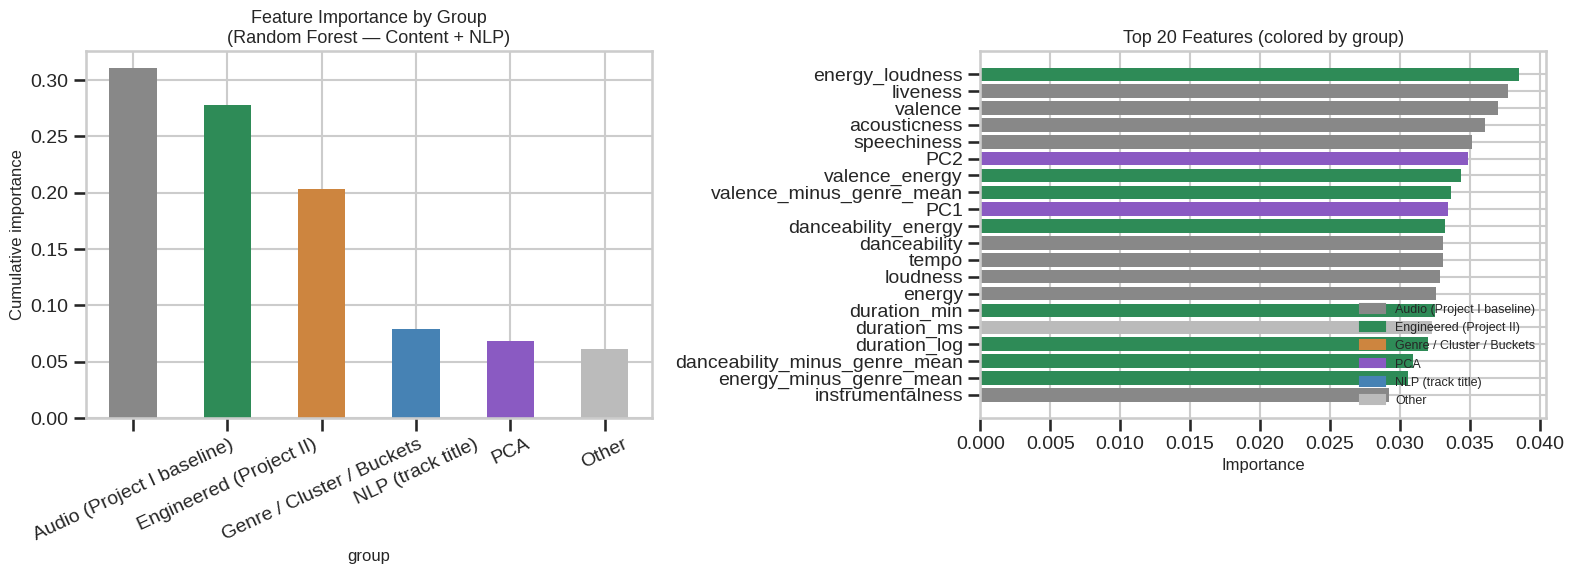


Group importance summary:


,group,total_importance
0,Audio (Project I baseline),0.3104
1,Engineered (Project II),0.2775
2,Genre / Cluster / Buckets,0.2034
3,NLP (track title),0.0790
4,PCA,0.0684
5,Other,0.0613



Top 20 individual features:


,feature,importance,group
0,energy_loudness,0.038554,Engineered (Project II)
1,liveness,0.037753,Audio (Project I baseline)
2,valence,0.037007,Audio (Project I baseline)
3,acousticness,0.036098,Audio (Project I baseline)
4,speechiness,0.035157,Audio (Project I baseline)
5,PC2,0.034898,PCA
6,valence_energy,0.034399,Engineered (Project II)
7,valence_minus_genre_mean,0.033634,Engineered (Project II)
8,PC1,0.033466,PCA
9,danceability_energy,0.033250,Engineered (Project II)


In [ ]:
# ── SECTION 8b: FEATURE IMPORTANCE BREAKDOWN — CONTENT + NLP ────────────────

# Use the Random Forest classifier from the Content + NLP section
rf_final = rfc_content

importances = pd.DataFrame({
    "feature": X_train_content.columns,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

# Define feature groups
engineered_project2_cols = {
    "energy_loudness",
    "danceability_energy",
    "valence_energy",
    "energy_minus_genre_mean",
    "danceability_minus_genre_mean",
    "valence_minus_genre_mean",
    "num_artists",
    "is_collab",
    "duration_min",
    "duration_log",
}

audio_baseline_cols = {
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "explicit",
}

def tag_group(f):
    if f.startswith("title_"):
        return "NLP (track title)"
    if f in engineered_project2_cols:
        return "Engineered (Project II)"
    if f.startswith("track_genre") or f.startswith("cluster") or f.startswith("duration_bucket"):
        return "Genre / Cluster / Buckets"
    if f.startswith("PC"):
        return "PCA"
    if f in audio_baseline_cols:
        return "Audio (Project I baseline)"
    return "Other"

importances["group"] = importances["feature"].apply(tag_group)

group_total = (
    importances.groupby("group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_map = {
    "Audio (Project I baseline)": "#888888",
    "Engineered (Project II)": "#2E8B57",
    "Genre / Cluster / Buckets": "#CD853F",
    "PCA": "#8A5AC2",
    "NLP (track title)": "#4682B4",
    "Other": "#BBBBBB",
}

group_colors = [color_map.get(g, "#BBBBBB") for g in group_total.index]
group_total.plot(kind="bar", ax=axes[0], color=group_colors)

axes[0].set_title("Feature Importance by Group\n(Random Forest — Content + NLP)", fontsize=13)
axes[0].set_ylabel("Cumulative importance")
axes[0].tick_params(axis="x", rotation=25)

top20 = importances.head(20).copy()
bar_colors = top20["group"].map(color_map).fillna("#BBBBBB")

axes[1].barh(top20["feature"], top20["importance"], color=bar_colors)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 Features (colored by group)", fontsize=13)
axes[1].set_xlabel("Importance")

from matplotlib.patches import Patch
legend_order = [g for g in color_map.keys() if g in importances["group"].unique()]
axes[1].legend(
    handles=[Patch(color=color_map[g], label=g) for g in legend_order],
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

print("\nGroup importance summary:")
display(group_total.round(4).reset_index().rename(columns={"index": "group", "importance": "total_importance"}))

print("\nTop 20 individual features:")
display(top20.reset_index(drop=True))

### Content + NLP + Last.fm External Artist Models

This section trains models that add Last.fm external artist-level popularity features on top of the Content + NLP feature set.

The goal is to test whether external audience signals from Last.fm, such as listener count, playcount, match status, and play-per-listener ratio, improve hit prediction beyond track-level content and title NLP features.

Internal Kaggle artist-prior features are still excluded here, so this section isolates the contribution of external Last.fm features.

In [ ]:
# ── SECTION 8c: CONTENT + NLP + LAST.FM MODELS ───────────────────────────────

# Start from the same full engineered design matrix
# X_all_full should already exist from Section 7, but rebuild defensively if needed.
if "X_all_full" not in globals():
    X_all_full = build_baseline_design_matrix(df)

# Define feature groups
artist_prior_cols = [
    "artist_song_count",
    "artist_avg_popularity",
    "artist_hit_rate",
]

lfm_feature_cols = [
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

metadata_cols = [
    "primary_artist",
    "lfm_artist_name",
    "lfm_api_status",
    "lfm_top_tag",
    "lfm_listeners",
    "lfm_playcount",
    "lfm_play_per_listener",
]

# Build Content + NLP + Last.fm feature matrix

# This model keeps Last.fm model columns but excludes:
# 1. internal Kaggle artist-prior features
# 2. raw Last.fm metadata / text / raw skewed fields
X_lfm_full = X_all_full.drop(
    columns=[
        c for c in artist_prior_cols + metadata_cols
        if c in X_all_full.columns
    ],
    errors="ignore"
)

# Convert boolean dummy columns to integer 0/1
bool_cols = X_lfm_full.select_dtypes(include=["bool"]).columns.tolist()

if bool_cols:
    print(f"Converting {len(bool_cols)} boolean dummy columns to 0/1.")
    X_lfm_full[bool_cols] = X_lfm_full[bool_cols].astype(int)

# Final defensive cleanup: remove any remaining non-numeric columns
non_numeric_cols = X_lfm_full.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    print("Dropping remaining non-numeric columns from Content + NLP + Last.fm model:")
    print(non_numeric_cols)
    X_lfm_full = X_lfm_full.drop(columns=non_numeric_cols, errors="ignore")

# Replace inf / NaN just in case
X_lfm_full = X_lfm_full.replace([np.inf, -np.inf], np.nan).fillna(0)

# Sanity checks
print("Remaining non-numeric columns:")
print(X_lfm_full.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nContent + NLP + Last.fm feature count:", X_lfm_full.shape[1])

print("\nNLP columns included:")
print([c for c in X_lfm_full.columns if c.startswith("title_")])

print("\nLast.fm columns included:")
print([c for c in X_lfm_full.columns if c.startswith("lfm_")])

print("\nArtist-prior columns included:")
print([c for c in X_lfm_full.columns if c in artist_prior_cols])

# Train/test split for Content + NLP + Last.fm model

X_train_lfm = X_lfm_full.iloc[train_idx].copy()
X_test_lfm = X_lfm_full.iloc[test_idx].copy()

scaler_lfm = StandardScaler()
X_train_lfm_scaled = scaler_lfm.fit_transform(X_train_lfm)
X_test_lfm_scaled = scaler_lfm.transform(X_test_lfm)

lfm_feature_names = X_lfm_full.columns.tolist()

# Content + NLP + Last.fm regression models

ridge_lfm = Ridge(alpha=1.0)

dt_lfm = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=10
)

rf_lfm = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ridge_lfm.fit(X_train_lfm_scaled, y_train_reg)
dt_lfm.fit(X_train_lfm, y_train_reg)
rf_lfm.fit(X_train_lfm, y_train_reg)

lfm_reg_rows = []

for name, model, Xte in [
    ("Ridge", ridge_lfm, X_test_lfm_scaled),
    ("Decision Tree", dt_lfm, X_test_lfm),
    ("Random Forest", rf_lfm, X_test_lfm),
]:
    m = reg_metrics(y_test_reg, model.predict(Xte))
    m["model"] = name
    m["version"] = "content_nlp_lastfm"
    m["n_features"] = Xte.shape[1]
    lfm_reg_rows.append(m)

lfm_reg_df = pd.DataFrame(lfm_reg_rows)

print("\n=== Content + NLP + Last.fm regression ===")
display(lfm_reg_df)

# Content + NLP + Last.fm classification models

lr_lfm = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

dtc_lfm = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=12,
    class_weight="balanced"
)

rfc_lfm = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

lr_lfm.fit(X_train_lfm_scaled, y_train_class)
dtc_lfm.fit(X_train_lfm, y_train_class)
rfc_lfm.fit(X_train_lfm, y_train_class)

lfm_clf_rows = []

for name, model, Xte in [
    ("Logistic Regression", lr_lfm, X_test_lfm_scaled),
    ("Decision Tree", dtc_lfm, X_test_lfm),
    ("Random Forest", rfc_lfm, X_test_lfm),
]:
    prob = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)

    m = clf_metrics(y_test_class, prob, pred)
    m["model"] = name
    m["version"] = "content_nlp_lastfm"
    m["n_features"] = Xte.shape[1]
    lfm_clf_rows.append(m)

lfm_clf_df = pd.DataFrame(lfm_clf_rows)

print("\n=== Content + NLP + Last.fm classification ===")
display(lfm_clf_df)

Converting 117 boolean dummy columns to 0/1.
Remaining non-numeric columns:
[]

Content + NLP + Last.fm feature count: 156

NLP columns included:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation']

Last.fm columns included:
['lfm_matched', 'lfm_listeners_log', 'lfm_playcount_log', 'lfm_play_per_listener_log']

Artist-prior columns included:
[]

=== Content + NLP + Last.fm regression ===


,RMSE,MAE,R2,model,version,n_features
0,18.810952,13.894459,0.287314,Ridge,content_nlp_lastfm,156
1,20.118601,16.039264,0.184785,Decision Tree,content_nlp_lastfm,156
2,13.034273,8.422715,0.657823,Random Forest,content_nlp_lastfm,156



=== Content + NLP + Last.fm classification ===


,accuracy,precision,recall,f1,roc_auc,model,version,n_features
0,0.756140,0.514783,0.812071,0.630122,0.846912,Logistic Regression,content_nlp_lastfm,156
1,0.743825,0.499441,0.673937,0.573714,0.797843,Decision Tree,content_nlp_lastfm,156
2,0.881579,0.868159,0.633196,0.732292,0.935404,Random Forest,content_nlp_lastfm,156


## 9. Supplementary Artist-Prior Model

This supplementary model adds leakage-safe artist-prior features to the Content + NLP feature set, including `artist_song_count`, `artist_avg_popularity`, and `artist_hit_rate`.

Because these artist-prior features are derived from the same popularity target within the dataset, this model is not treated as the main content-based model. Instead, it is reported as a supplementary benchmark to show how much prediction improves when artist historical signals are included.

Last.fm features are excluded here so that the effect of internal artist-prior features can be compared separately from external Last.fm artist popularity signals.

In [ ]:
# ── SECTION 9: SUPPLEMENTARY INTERNAL ARTIST-PRIOR MODEL ────────────────────

# Build the full engineered design matrix
X_up_full = build_baseline_design_matrix(df)

# Define feature groups

artist_prior_cols = [
    "artist_song_count",
    "artist_avg_popularity",
    "artist_hit_rate",
]

lfm_feature_cols = [
    "lfm_matched",
    "lfm_listeners_log",
    "lfm_playcount_log",
    "lfm_play_per_listener_log",
]

metadata_cols = [
    "primary_artist",
    "lfm_artist_name",
    "lfm_api_status",
    "lfm_top_tag",
    "lfm_listeners",
    "lfm_playcount",
    "lfm_play_per_listener",
]

# Build Content + NLP + internal artist-prior matrix

# Keep artist-prior features.
# Exclude external Last.fm features and metadata/raw fields.
X_up_full = X_up_full.drop(
    columns=[
        c for c in lfm_feature_cols + metadata_cols
        if c in X_up_full.columns
    ],
    errors="ignore"
)

# Convert boolean dummy columns to integer 0/1
bool_cols = X_up_full.select_dtypes(include=["bool"]).columns.tolist()

if bool_cols:
    print(f"Converting {len(bool_cols)} boolean dummy columns to 0/1.")
    X_up_full[bool_cols] = X_up_full[bool_cols].astype(int)

# Final defensive cleanup: remove any remaining non-numeric columns
non_numeric_cols = X_up_full.select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    print("Dropping remaining non-numeric columns from artist-prior model:")
    print(non_numeric_cols)
    X_up_full = X_up_full.drop(columns=non_numeric_cols, errors="ignore")

X_up_full = X_up_full.replace([np.inf, -np.inf], np.nan).fillna(0)


print("Remaining non-numeric columns:")
print(X_up_full.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nArtist-prior supplementary feature count:", X_up_full.shape[1])

print("\nArtist-prior columns included:")
print([c for c in X_up_full.columns if c in artist_prior_cols])

print("\nLast.fm columns included:")
print([c for c in X_up_full.columns if c.startswith("lfm_")])

print("\nNLP columns included:")
print([c for c in X_up_full.columns if c.startswith("title_")])

X_train_up = X_up_full.iloc[train_idx].copy()
X_test_up = X_up_full.iloc[test_idx].copy()

scaler_up = StandardScaler()
X_train_up_scaled = scaler_up.fit_transform(X_train_up)
X_test_up_scaled = scaler_up.transform(X_test_up)

up_feature_names = X_up_full.columns.tolist()

# Artist-prior supplementary regression models

ridge_u = Ridge(alpha=1.0)

dt_u = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=10
)

rf_u = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ridge_u.fit(X_train_up_scaled, y_train_reg)
dt_u.fit(X_train_up, y_train_reg)
rf_u.fit(X_train_up, y_train_reg)

up_reg_rows = []

for name, model, Xte in [
    ("Ridge", ridge_u, X_test_up_scaled),
    ("Decision Tree", dt_u, X_test_up),
    ("Random Forest", rf_u, X_test_up),
]:
    m = reg_metrics(y_test_reg, model.predict(Xte))
    m["model"] = name
    m["version"] = "artist_prior_supplement"
    m["n_features"] = Xte.shape[1]
    up_reg_rows.append(m)

up_reg_df = pd.DataFrame(up_reg_rows)

print("\n=== Supplementary internal artist-prior regression ===")
display(up_reg_df)

# Artist-prior supplementary classification models

lr_u = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

dtc_u = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=12,
    class_weight="balanced"
)

rfc_u = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

lr_u.fit(X_train_up_scaled, y_train_class)
dtc_u.fit(X_train_up, y_train_class)
rfc_u.fit(X_train_up, y_train_class)

up_clf_rows = []

for name, model, Xte in [
    ("Logistic Regression", lr_u, X_test_up_scaled),
    ("Decision Tree", dtc_u, X_test_up),
    ("Random Forest", rfc_u, X_test_up),
]:
    prob = model.predict_proba(Xte)[:, 1]
    pred = model.predict(Xte)

    m = clf_metrics(y_test_class, prob, pred)
    m["model"] = name
    m["version"] = "artist_prior_supplement"
    m["n_features"] = Xte.shape[1]
    up_clf_rows.append(m)

up_clf_df = pd.DataFrame(up_clf_rows)

print("\n=== Supplementary internal artist-prior classification ===")
display(up_clf_df)

Converting 117 boolean dummy columns to 0/1.
Remaining non-numeric columns:
[]

Artist-prior supplementary feature count: 155

Artist-prior columns included:
['artist_song_count', 'artist_avg_popularity', 'artist_hit_rate']

Last.fm columns included:
[]

NLP columns included:
['title_sentiment', 'title_word_count', 'title_char_len', 'title_has_feat', 'title_has_remix', 'title_is_short', 'title_has_love', 'title_has_number', 'title_exclamation']

=== Supplementary internal artist-prior regression ===


,RMSE,MAE,R2,model,version,n_features
0,14.654477,9.512757,0.567469,Ridge,artist_prior_supplement,155
1,16.404440,9.583460,0.458000,Decision Tree,artist_prior_supplement,155
2,14.674079,8.746338,0.566311,Random Forest,artist_prior_supplement,155



=== Supplementary internal artist-prior classification ===


,accuracy,precision,recall,f1,roc_auc,model,version,n_features
0,0.846386,0.664445,0.806996,0.728816,0.913189,Logistic Regression,artist_prior_supplement,155
1,0.847789,0.696433,0.717833,0.706971,0.852081,Decision Tree,artist_prior_supplement,155
2,0.892421,0.842301,0.712894,0.772214,0.943440,Random Forest,artist_prior_supplement,155


## 10. Model Comparison

This section compares three model versions:

1. **Baseline:** the original Project I model using the original Spotify features.
2. **Content upgraded (Content + NLP, Content + NLP + Last.fm):** the main Project II model using engineered content features, PCA components, and cluster labels, excluding artist-prior features.
3. **Artist-prior supplement (Content + NLP + internal artist-prior features):** a supplementary model that adds leakage-safe artist-level historical aggregate features.

The goal is to separate the value of content-based modeling from the additional predictive power of artist-prior signals.

In [ ]:
# ── SECTION 10: MODEL COMPARISON ────────────────────────────────────────────

# Collect available regression result tables
reg_tables = []

if "baseline_reg_df" in globals():
    reg_tables.append(baseline_reg_df)

if "content_reg_df" in globals():
    reg_tables.append(content_reg_df)

if "lfm_reg_df" in globals():
    reg_tables.append(lfm_reg_df)

if "up_reg_df" in globals():
    reg_tables.append(up_reg_df)

reg_compare_all = pd.concat(reg_tables, ignore_index=True)

# Collect available classification result tables
clf_tables = []

if "baseline_clf_df" in globals():
    clf_tables.append(baseline_clf_df)

if "content_clf_df" in globals():
    clf_tables.append(content_clf_df)

if "lfm_clf_df" in globals():
    clf_tables.append(lfm_clf_df)

if "up_clf_df" in globals():
    clf_tables.append(up_clf_df)

clf_compare_all = pd.concat(clf_tables, ignore_index=True)

# Optional: standardize version names for cleaner display
version_order = {
    "baseline": 0,
    "content_only": 1,
    "content_only_upgraded": 1,
    "content_nlp": 2,
    "content_nlp_lastfm": 3,
    "artist_prior_supplement": 4,
}

reg_compare_all["version_order"] = reg_compare_all["version"].map(version_order).fillna(99)
clf_compare_all["version_order"] = clf_compare_all["version"].map(version_order).fillna(99)

reg_compare_all = (
    reg_compare_all
    .sort_values(["version_order", "model"])
    .drop(columns=["version_order"])
    .reset_index(drop=True)
)

clf_compare_all = (
    clf_compare_all
    .sort_values(["version_order", "model"])
    .drop(columns=["version_order"])
    .reset_index(drop=True)
)

print("=== Regression comparison: baseline vs Content + NLP vs Last.fm vs artist-prior ===")
display(reg_compare_all)

print("\n=== Classification comparison: baseline vs Content + NLP vs Last.fm vs artist-prior ===")
display(clf_compare_all)

=== Regression comparison: baseline vs Content + NLP vs Last.fm vs artist-prior ===


,RMSE,MAE,R2,model,version,n_features
0,21.052010,17.198212,0.107385,Decision Tree,baseline,NaN
1,15.436618,10.453041,0.520066,Random Forest,baseline,NaN
2,19.138325,14.088480,0.262292,Ridge,baseline,NaN
3,20.925570,17.119995,0.118076,Decision Tree,content_nlp,152.0
4,15.076898,10.424979,0.542174,Random Forest,content_nlp,152.0
5,18.935671,13.994380,0.277832,Ridge,content_nlp,152.0
6,19.006511,15.069082,0.272419,XGBoost,content_nlp,152.0
7,20.118601,16.039264,0.184785,Decision Tree,content_nlp_lastfm,156.0
8,13.034273,8.422715,0.657823,Random Forest,content_nlp_lastfm,156.0
9,18.810952,13.894459,0.287314,Ridge,content_nlp_lastfm,156.0



=== Classification comparison: baseline vs Content + NLP vs Last.fm vs artist-prior ===


,accuracy,precision,recall,f1,roc_auc,model,version,n_features
0,0.538456,0.325746,0.751852,0.454553,0.662715,Decision Tree,baseline,NaN
1,0.704526,0.454118,0.767764,0.570686,0.805817,Logistic Regression,baseline,NaN
2,0.844000,0.790917,0.530316,0.634915,0.895567,Random Forest,baseline,NaN
3,0.710351,0.441380,0.498354,0.468140,0.678377,Decision Tree,content_nlp,152.0
4,0.713684,0.464073,0.770782,0.579338,0.812966,Logistic Regression,content_nlp,152.0
5,0.850140,0.840822,0.510837,0.635549,0.901946,Random Forest,content_nlp,152.0
6,0.704632,0.454332,0.769684,0.571385,0.814577,XGBoost,content_nlp,152.0
7,0.743825,0.499441,0.673937,0.573714,0.797843,Decision Tree,content_nlp_lastfm,156.0
8,0.756140,0.514783,0.812071,0.630122,0.846912,Logistic Regression,content_nlp_lastfm,156.0
9,0.881579,0.868159,0.633196,0.732292,0.935404,Random Forest,content_nlp_lastfm,156.0


## 11. Business Evaluation

Traditional accuracy metrics evaluate overall prediction performance, but the business problem is about early promotion prioritization. In practice, a music platform may only have enough resources to strongly promote a small subset of tracks.

To mimic this setting, we rank test-set songs by model score and select the top predicted decile, or top 10%. We then evaluate how many true hits are captured in this priority group.

For regression models, songs are ranked by predicted popularity. For classification models, songs are ranked by predicted hit probability.

We compare the baseline model, the content+nlp upgraded model, and the supplementary artist-prior model using:
- **hit capture rate:** the share of all true hits captured in the top decile;
- **precision in top decile:** the share of selected top-decile songs that are true hits;
- **lift vs random:** how much better the model is than random selection.

In [ ]:
# ── SECTION 11: BUSINESS EVALUATION ─────────────────────────────────────────

def top_decile_lift(y_true_hit, scores, frac=0.1, n_mc=500, seed=RANDOM_STATE):
    """
    Evaluate how many true hits are captured in the top predicted fraction.

    This simulates a business scenario where a label, playlist curator,
    or marketing team can only prioritize the top 10% of tracks.
    """
    n = len(y_true_hit)
    k = max(1, int(np.floor(frac * n)))

    order = np.argsort(-scores)
    top = order[:k]

    if hasattr(y_true_hit, "iloc"):
        hits_in_top = int(y_true_hit.iloc[top].sum())
    else:
        hits_in_top = int(y_true_hit[top].sum())

    total_hits = int(np.sum(y_true_hit))
    capture = hits_in_top / total_hits if total_hits else float("nan")
    precision_top = hits_in_top / k

    rng = np.random.RandomState(seed)
    random_captures = []

    for _ in range(n_mc):
        perm = rng.permutation(n)[:k]

        if hasattr(y_true_hit, "iloc"):
            random_hits = int(y_true_hit.iloc[perm].sum())
        else:
            random_hits = int(y_true_hit[perm].sum())

        random_captures.append(random_hits)

    random_capture_mean = (
        np.array(random_captures) / total_hits
    ).mean() if total_hits else float("nan")

    return {
        "n_test": n,
        "top_k": k,
        "hits_total": total_hits,
        "hits_in_top_k": hits_in_top,
        "hit_capture_rate": capture,
        "precision_in_top_k": precision_top,
        "random_capture_mean": float(random_capture_mean),
    }


y_hit_test = pd.Series(y_test_class).reset_index(drop=True)

biz_rows = []


# Baseline Random Forest business evaluation

if "rf_b" in globals() and "rfc_b" in globals():
    baseline_pred_pop = rf_b.predict(X_test_base)
    baseline_prob_hit = rfc_b.predict_proba(X_test_base)[:, 1]

    biz_baseline_reg = top_decile_lift(
        y_hit_test,
        baseline_pred_pop
    )
    biz_baseline_reg["method"] = "Baseline RF regression"
    biz_baseline_reg["model_family"] = "baseline"
    biz_rows.append(biz_baseline_reg)

    biz_baseline_clf = top_decile_lift(
        y_hit_test,
        baseline_prob_hit
    )
    biz_baseline_clf["method"] = "Baseline RF classifier"
    biz_baseline_clf["model_family"] = "baseline"
    biz_rows.append(biz_baseline_clf)


# Content + NLP Random Forest business evaluation

if "rf_content" in globals() and "rfc_content" in globals():
    content_pred_pop = rf_content.predict(X_test_content)
    content_prob_hit = rfc_content.predict_proba(X_test_content)[:, 1]

    biz_content_reg = top_decile_lift(
        y_hit_test,
        content_pred_pop
    )
    biz_content_reg["method"] = "Content + NLP RF regression"
    biz_content_reg["model_family"] = "content_nlp"
    biz_rows.append(biz_content_reg)

    biz_content_clf = top_decile_lift(
        y_hit_test,
        content_prob_hit
    )
    biz_content_clf["method"] = "Content + NLP RF classifier"
    biz_content_clf["model_family"] = "content_nlp"
    biz_rows.append(biz_content_clf)


# Content + NLP + Last.fm Random Forest business evaluation

if "rf_lfm" in globals() and "rfc_lfm" in globals():
    lfm_pred_pop = rf_lfm.predict(X_test_lfm)
    lfm_prob_hit = rfc_lfm.predict_proba(X_test_lfm)[:, 1]

    biz_lfm_reg = top_decile_lift(
        y_hit_test,
        lfm_pred_pop
    )
    biz_lfm_reg["method"] = "Content + NLP + Last.fm RF regression"
    biz_lfm_reg["model_family"] = "content_nlp_lastfm"
    biz_rows.append(biz_lfm_reg)

    biz_lfm_clf = top_decile_lift(
        y_hit_test,
        lfm_prob_hit
    )
    biz_lfm_clf["method"] = "Content + NLP + Last.fm RF classifier"
    biz_lfm_clf["model_family"] = "content_nlp_lastfm"
    biz_rows.append(biz_lfm_clf)


# Supplementary internal artist-prior Random Forest business evaluation

if "rf_u" in globals() and "rfc_u" in globals():
    artist_pred_pop = rf_u.predict(X_test_up)
    artist_prob_hit = rfc_u.predict_proba(X_test_up)[:, 1]

    biz_artist_reg = top_decile_lift(
        y_hit_test,
        artist_pred_pop
    )
    biz_artist_reg["method"] = "Artist-prior RF regression"
    biz_artist_reg["model_family"] = "artist_prior_supplement"
    biz_rows.append(biz_artist_reg)

    biz_artist_clf = top_decile_lift(
        y_hit_test,
        artist_prob_hit
    )
    biz_artist_clf["method"] = "Artist-prior RF classifier"
    biz_artist_clf["model_family"] = "artist_prior_supplement"
    biz_rows.append(biz_artist_clf)


# Combine business evaluation results

biz_compare_all = pd.DataFrame(biz_rows)

biz_one_all = biz_compare_all[
    [
        "model_family",
        "method",
        "hit_capture_rate",
        "random_capture_mean",
        "precision_in_top_k",
        "hits_in_top_k",
        "top_k",
        "hits_total",
    ]
].copy()

biz_one_all["lift_vs_random"] = (
    biz_one_all["hit_capture_rate"] / biz_one_all["random_capture_mean"]
)

# Optional ordering
family_order = {
    "baseline": 0,
    "content_nlp": 1,
    "content_nlp_lastfm": 2,
    "artist_prior_supplement": 3,
}

biz_one_all["family_order"] = biz_one_all["model_family"].map(family_order).fillna(99)

biz_one_all = (
    biz_one_all
    .sort_values(["family_order", "method"])
    .drop(columns=["family_order"])
    .reset_index(drop=True)
)

print("=== Business evaluation: baseline vs Content + NLP vs Last.fm vs artist-prior ===")
display(biz_one_all.round(4))

=== Business evaluation: baseline vs Content + NLP vs Last.fm vs artist-prior ===


,model_family,method,hit_capture_rate,random_capture_mean,precision_in_top_k,hits_in_top_k,top_k,hits_total,lift_vs_random
0,baseline,Baseline RF classifier,0.3243,0.0999,0.8295,2364,2850,7290,3.2459
1,baseline,Baseline RF regression,0.3255,0.0999,0.8326,2373,2850,7290,3.2583
2,content_nlp,Content + NLP RF classifier,0.3450,0.0999,0.8825,2515,2850,7290,3.4533
3,content_nlp,Content + NLP RF regression,0.3270,0.0999,0.8365,2384,2850,7290,3.2734
4,content_nlp_lastfm,Content + NLP + Last.fm RF classifier,0.3632,0.0999,0.9291,2648,2850,7290,3.6359
5,content_nlp_lastfm,Content + NLP + Last.fm RF regression,0.3578,0.0999,0.9151,2608,2850,7290,3.5810
6,artist_prior_supplement,Artist-prior RF classifier,0.3726,0.0999,0.9530,2716,2850,7290,3.7293
7,artist_prior_supplement,Artist-prior RF regression,0.3455,0.0999,0.8839,2519,2850,7290,3.4588


## 12. Feature Importance

We use Random Forest feature importance to inspect which variables each model relies on.

For the baseline model, feature importance shows which original Spotify features drive prediction. For the content upgraded model, feature importance helps identify which engineered content signals, PCA components, and cluster indicators contribute to ranking potential hits. For the supplementary artist-prior model, feature importance is used mainly as a diagnostic check, since artist-prior features are expected to be highly predictive and may dominate the model.

This section is interpretive rather than causal: high feature importance means the model used the feature for prediction, not that the feature directly causes popularity.

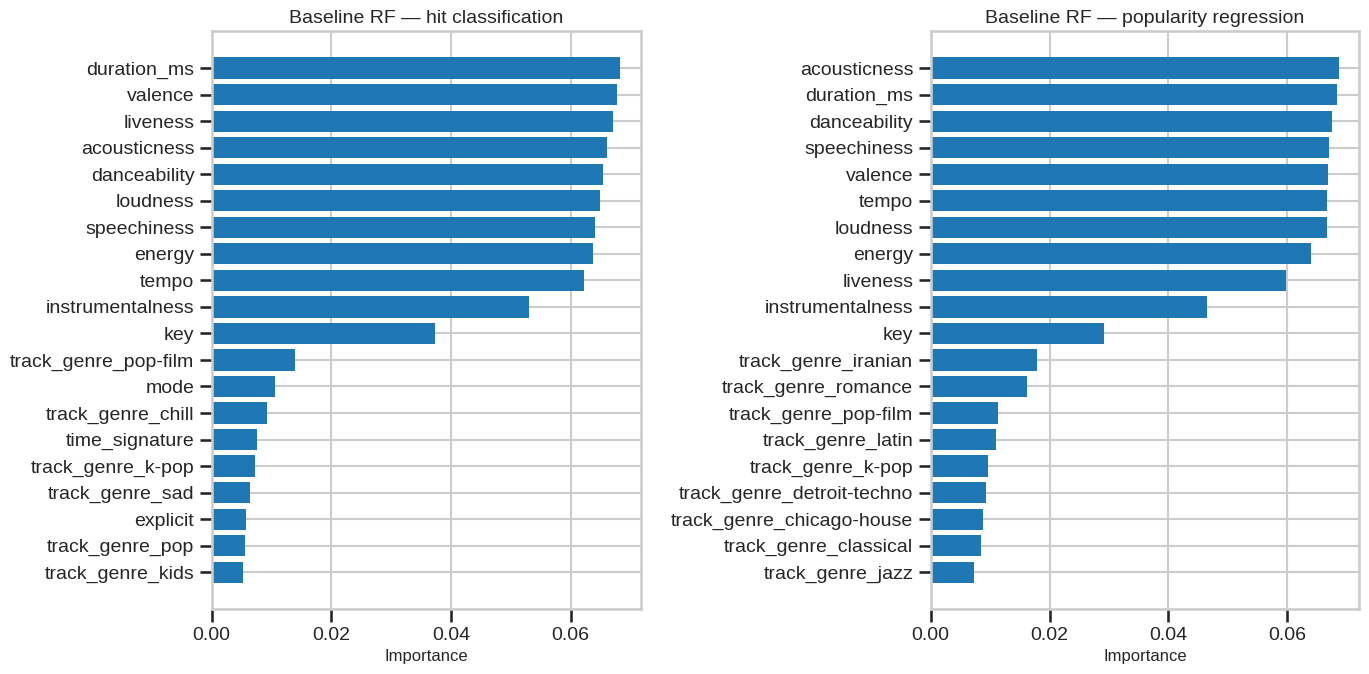

=== Baseline RF hit classification feature importance ===


,feature,importance
0,duration_ms,0.068271
1,valence,0.067829
2,liveness,0.067137
3,acousticness,0.066057
4,danceability,0.065487
5,loudness,0.064956
6,speechiness,0.064008
7,energy,0.063729
8,tempo,0.062218
9,instrumentalness,0.053112



=== Baseline RF popularity regression feature importance ===


,feature,importance
0,acousticness,0.068665
1,duration_ms,0.068396
2,danceability,0.067563
3,speechiness,0.066975
4,valence,0.066778
5,tempo,0.066659
6,loudness,0.066604
7,energy,0.063981
8,liveness,0.059795
9,instrumentalness,0.046536


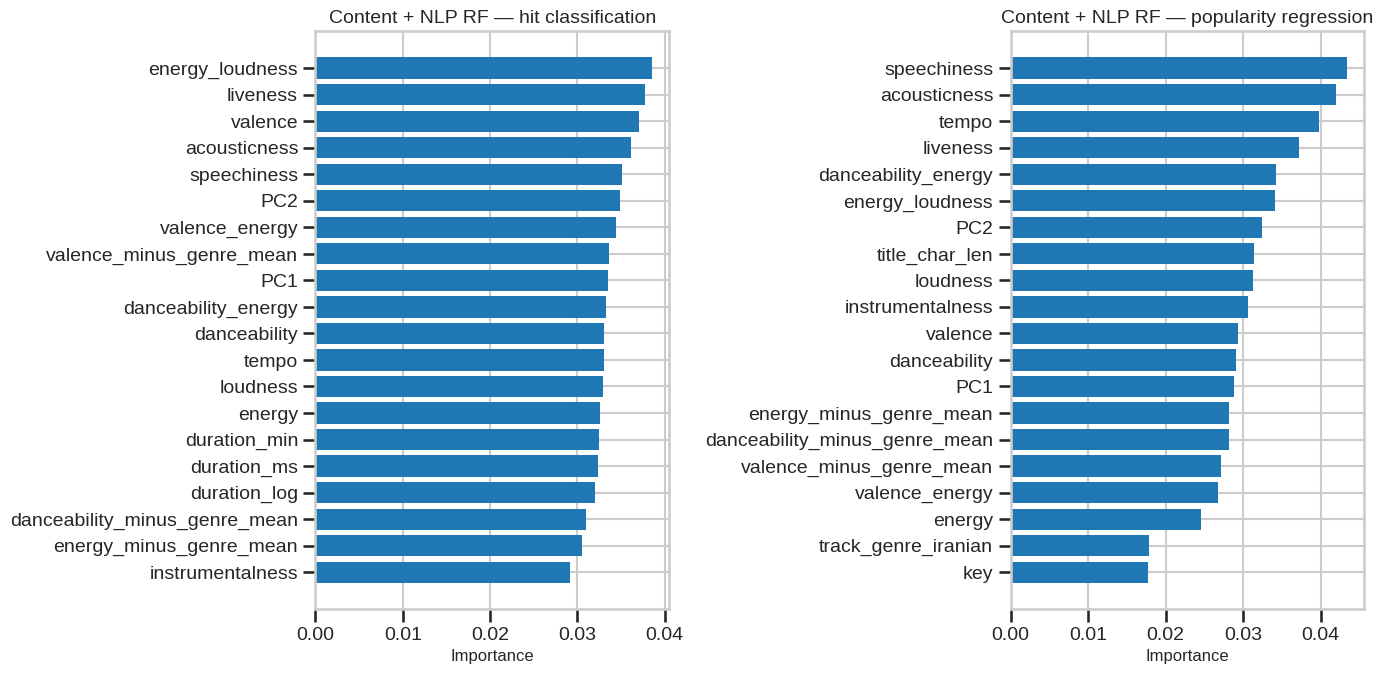

=== Content + NLP RF hit classification feature importance ===


,feature,importance
0,energy_loudness,0.038554
1,liveness,0.037753
2,valence,0.037007
3,acousticness,0.036098
4,speechiness,0.035157
5,PC2,0.034898
6,valence_energy,0.034399
7,valence_minus_genre_mean,0.033634
8,PC1,0.033466
9,danceability_energy,0.033250



=== Content + NLP RF popularity regression feature importance ===


,feature,importance
0,speechiness,0.043418
1,acousticness,0.041986
2,tempo,0.039713
3,liveness,0.037202
4,danceability_energy,0.034166
5,energy_loudness,0.034090
6,PC2,0.032471
7,title_char_len,0.031418
8,loudness,0.031245
9,instrumentalness,0.030553


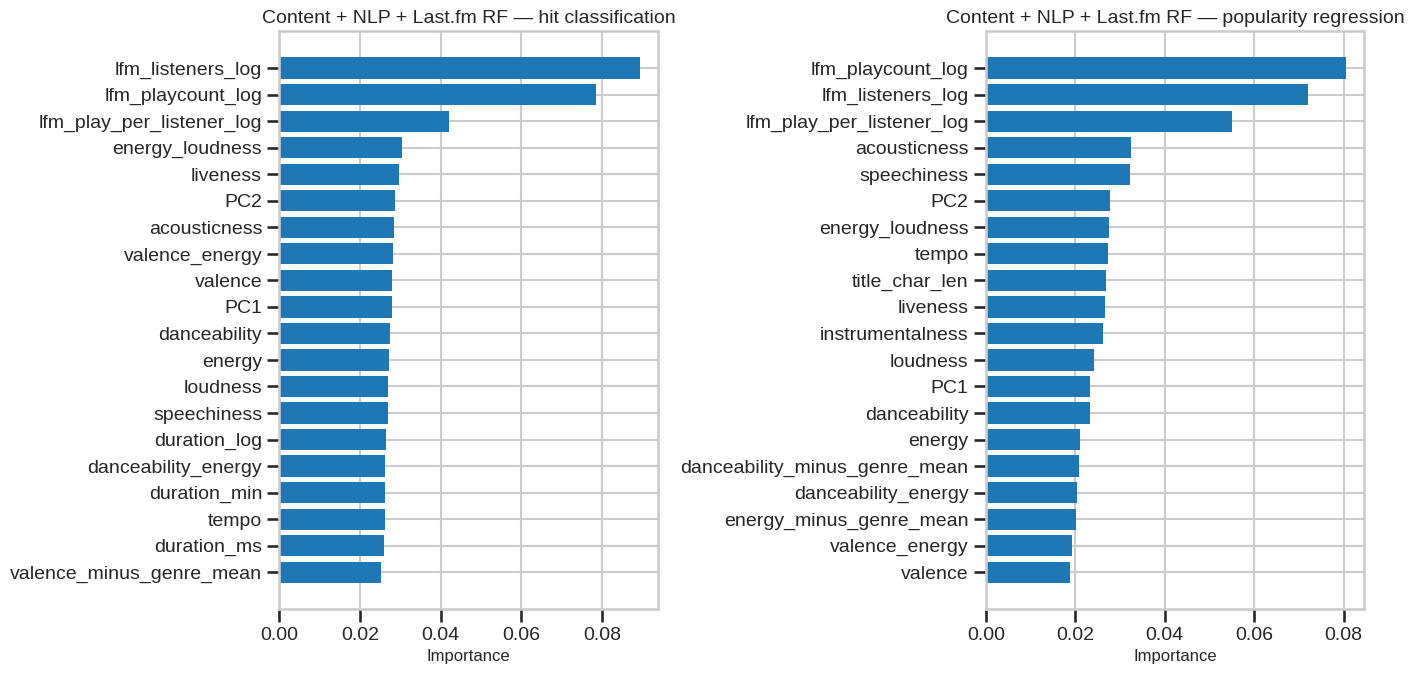

=== Content + NLP + Last.fm RF hit classification feature importance ===


,feature,importance
0,lfm_listeners_log,0.089383
1,lfm_playcount_log,0.078565
2,lfm_play_per_listener_log,0.042106
3,energy_loudness,0.030495
4,liveness,0.029586
5,PC2,0.028577
6,acousticness,0.028456
7,valence_energy,0.028233
8,valence,0.027940
9,PC1,0.027850



=== Content + NLP + Last.fm RF popularity regression feature importance ===


,feature,importance
0,lfm_playcount_log,0.080579
1,lfm_listeners_log,0.071967
2,lfm_play_per_listener_log,0.054975
3,acousticness,0.032515
4,speechiness,0.032304
5,PC2,0.027796
6,energy_loudness,0.027481
7,tempo,0.027316
8,title_char_len,0.026787
9,liveness,0.026597



=== Last.fm feature importances in classification model ===


,feature,importance
0,lfm_listeners_log,0.089383
1,lfm_playcount_log,0.078565
2,lfm_play_per_listener_log,0.042106
3,lfm_matched,0.000094



=== Last.fm feature importances in regression model ===


,feature,importance
0,lfm_playcount_log,0.080579
1,lfm_listeners_log,0.071967
2,lfm_play_per_listener_log,0.054975
3,lfm_matched,0.000051


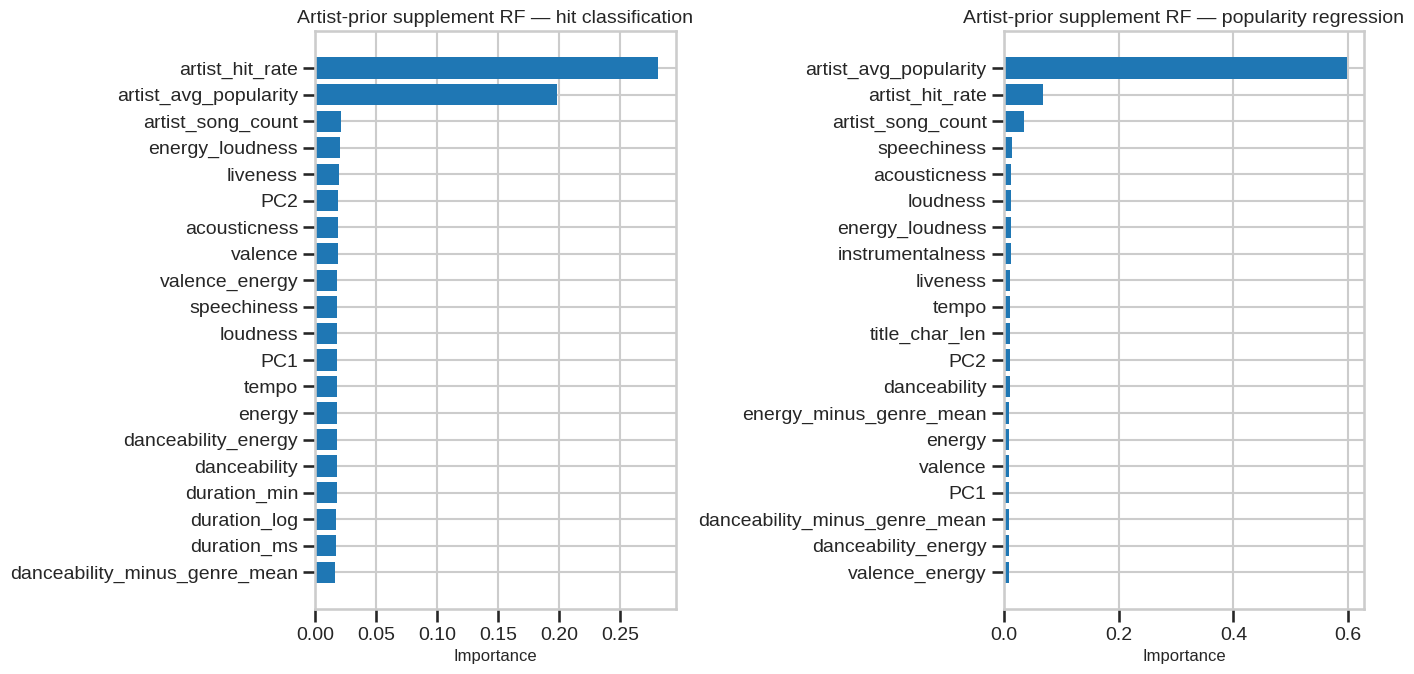

=== Artist-prior supplement RF hit classification feature importance ===


,feature,importance
0,artist_hit_rate,0.281239
1,artist_avg_popularity,0.198017
2,artist_song_count,0.021103
3,energy_loudness,0.020209
4,liveness,0.019624
5,PC2,0.018750
6,acousticness,0.018584
7,valence,0.018394
8,valence_energy,0.018019
9,speechiness,0.018000



=== Artist-prior supplement RF popularity regression feature importance ===


,feature,importance
0,artist_avg_popularity,0.598005
1,artist_hit_rate,0.068215
2,artist_song_count,0.035162
3,speechiness,0.013145
4,acousticness,0.012699
5,loudness,0.012389
6,energy_loudness,0.012168
7,instrumentalness,0.011549
8,liveness,0.011258
9,tempo,0.011225



=== Internal artist-prior feature importances in classification model ===


,feature,importance
0,artist_hit_rate,0.281239
1,artist_avg_popularity,0.198017
2,artist_song_count,0.021103



=== Internal artist-prior feature importances in regression model ===


,feature,importance
0,artist_avg_popularity,0.598005
1,artist_hit_rate,0.068215
2,artist_song_count,0.035162


In [ ]:
# ── SECTION 12: FEATURE IMPORTANCE ──────────────────────────────────────────

def get_rf_importance(model, feature_names, top_n=20):
    """
    Return top_n feature importances from a fitted Random Forest model.
    """
    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def plot_importance_pair(imp_hit, imp_pop, title_prefix):
    """
    Plot classification and regression feature importances side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].barh(
        imp_hit["feature"][::-1],
        imp_hit["importance"][::-1]
    )
    axes[0].set_title(f"{title_prefix} — hit classification")
    axes[0].set_xlabel("Importance")

    axes[1].barh(
        imp_pop["feature"][::-1],
        imp_pop["importance"][::-1]
    )
    axes[1].set_title(f"{title_prefix} — popularity regression")
    axes[1].set_xlabel("Importance")

    plt.tight_layout()
    plt.show()


# Baseline Random Forest feature importance

base_feature_names = X_train_base.columns.tolist()

imp_hit_baseline = get_rf_importance(
    rfc_b,
    base_feature_names,
    top_n=20
)

imp_pop_baseline = get_rf_importance(
    rf_b,
    base_feature_names,
    top_n=20
)

plot_importance_pair(
    imp_hit_baseline,
    imp_pop_baseline,
    "Baseline RF"
)

print("=== Baseline RF hit classification feature importance ===")
display(imp_hit_baseline)

print("\n=== Baseline RF popularity regression feature importance ===")
display(imp_pop_baseline)


# Content + NLP Random Forest feature importance

content_feature_names = X_train_content.columns.tolist()

imp_hit_content = get_rf_importance(
    rfc_content,
    content_feature_names,
    top_n=20
)

imp_pop_content = get_rf_importance(
    rf_content,
    content_feature_names,
    top_n=20
)

plot_importance_pair(
    imp_hit_content,
    imp_pop_content,
    "Content + NLP RF"
)

print("=== Content + NLP RF hit classification feature importance ===")
display(imp_hit_content)

print("\n=== Content + NLP RF popularity regression feature importance ===")
display(imp_pop_content)


# Content + NLP + Last.fm Random Forest feature importance

if "rfc_lfm" in globals() and "rf_lfm" in globals():
    lfm_feature_names = X_train_lfm.columns.tolist()

    imp_hit_lfm = get_rf_importance(
        rfc_lfm,
        lfm_feature_names,
        top_n=20
    )

    imp_pop_lfm = get_rf_importance(
        rf_lfm,
        lfm_feature_names,
        top_n=20
    )

    plot_importance_pair(
        imp_hit_lfm,
        imp_pop_lfm,
        "Content + NLP + Last.fm RF"
    )

    print("=== Content + NLP + Last.fm RF hit classification feature importance ===")
    display(imp_hit_lfm)

    print("\n=== Content + NLP + Last.fm RF popularity regression feature importance ===")
    display(imp_pop_lfm)

    print("\n=== Last.fm feature importances in classification model ===")
    display(
        pd.DataFrame({
            "feature": lfm_feature_names,
            "importance": rfc_lfm.feature_importances_
        })
        .query("feature.str.startswith('lfm_')", engine="python")
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("\n=== Last.fm feature importances in regression model ===")
    display(
        pd.DataFrame({
            "feature": lfm_feature_names,
            "importance": rf_lfm.feature_importances_
        })
        .query("feature.str.startswith('lfm_')", engine="python")
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    print("Content + NLP + Last.fm models not found. Skipping Last.fm feature importance.")


# Supplementary internal artist-prior Random Forest feature importance

up_feature_names = X_train_up.columns.tolist()

imp_hit_artist = get_rf_importance(
    rfc_u,
    up_feature_names,
    top_n=20
)

imp_pop_artist = get_rf_importance(
    rf_u,
    up_feature_names,
    top_n=20
)

plot_importance_pair(
    imp_hit_artist,
    imp_pop_artist,
    "Artist-prior supplement RF"
)

print("=== Artist-prior supplement RF hit classification feature importance ===")
display(imp_hit_artist)

print("\n=== Artist-prior supplement RF popularity regression feature importance ===")
display(imp_pop_artist)

print("\n=== Internal artist-prior feature importances in classification model ===")
display(
    pd.DataFrame({
        "feature": up_feature_names,
        "importance": rfc_u.feature_importances_
    })
    .query("feature in ['artist_song_count', 'artist_avg_popularity', 'artist_hit_rate']")
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Internal artist-prior feature importances in regression model ===")
display(
    pd.DataFrame({
        "feature": up_feature_names,
        "importance": rf_u.feature_importances_
    })
    .query("feature in ['artist_song_count', 'artist_avg_popularity', 'artist_hit_rate']")
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
# ── FEATURE GROUP IMPORTANCE SUMMARY ────────────────────────────────────────

engineered_project2_cols = {
    "energy_loudness",
    "danceability_energy",
    "valence_energy",
    "energy_minus_genre_mean",
    "danceability_minus_genre_mean",
    "valence_minus_genre_mean",
    "num_artists",
    "is_collab",
    "duration_min",
    "duration_log",
}

audio_baseline_cols = {
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "explicit",
}

artist_prior_cols = {
    "artist_song_count",
    "artist_avg_popularity",
    "artist_hit_rate",
}

def tag_feature_group(feature):
    if feature.startswith("title_"):
        return "NLP title features"
    if feature.startswith("lfm_"):
        return "Last.fm external artist features"
    if feature in artist_prior_cols:
        return "Internal artist-prior features"
    if feature in engineered_project2_cols:
        return "Engineered content features"
    if feature.startswith("track_genre") or feature.startswith("cluster") or feature.startswith("duration_bucket"):
        return "Genre / cluster / bucket features"
    if feature.startswith("PC"):
        return "PCA audio components"
    if feature in audio_baseline_cols:
        return "Original Spotify audio features"
    return "Other"


def summarize_group_importance(model, feature_names, model_label):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    importance_df["group"] = importance_df["feature"].apply(tag_feature_group)

    group_df = (
        importance_df
        .groupby("group")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    group_df["model"] = model_label

    return group_df


group_importance_tables = []

group_importance_tables.append(
    summarize_group_importance(
        rfc_content,
        X_train_content.columns.tolist(),
        "Content + NLP RF classifier"
    )
)

if "rfc_lfm" in globals():
    group_importance_tables.append(
        summarize_group_importance(
            rfc_lfm,
            X_train_lfm.columns.tolist(),
            "Content + NLP + Last.fm RF classifier"
        )
    )

group_importance_tables.append(
    summarize_group_importance(
        rfc_u,
        X_train_up.columns.tolist(),
        "Artist-prior RF classifier"
    )
)

group_importance_summary = pd.concat(
    group_importance_tables,
    ignore_index=True
)

print("=== Feature group importance summary ===")
display(group_importance_summary)

=== Feature group importance summary ===


,group,importance,model
0,Original Spotify audio features,0.310388,Content + NLP RF classifier
1,Engineered content features,0.277526,Content + NLP RF classifier
2,Genre / cluster / bucket features,0.203394,Content + NLP RF classifier
3,NLP title features,0.079030,Content + NLP RF classifier
4,PCA audio components,0.068364,Content + NLP RF classifier
5,Other,0.061298,Content + NLP RF classifier
6,Original Spotify audio features,0.245853,Content + NLP + Last.fm RF classifier
7,Engineered content features,0.224212,Content + NLP + Last.fm RF classifier
8,Last.fm external artist features,0.210148,Content + NLP + Last.fm RF classifier
9,Genre / cluster / bucket features,0.149920,Content + NLP + Last.fm RF classifier


## 13. Final Tables

This section organizes the final results into slide-ready and report-ready tables.

We summarize model performance across the three versions: baseline, content-only upgraded, and supplementary artist-prior model. We also prepare the cluster summary and top-decile business evaluation table for interpretation and presentation.

In [ ]:
# ── SECTION 13: FINAL TABLES ────────────────────────────────────────────────
# Version ordering and display labels

version_order = [
    "baseline",
    "content_nlp",
    "content_nlp_lastfm",
    "artist_prior_supplement",
]

version_labels = {
    "baseline": "Baseline",
    "content_nlp": "Content + NLP",
    "content_nlp_lastfm": "Content + NLP + Last.fm",
    "artist_prior_supplement": "Artist-prior supplement",
}

# Make copies so we do not accidentally modify the original comparison tables
reg_final = reg_compare_all.copy()
clf_final = clf_compare_all.copy()

# Optional: make version names cleaner for display
reg_final["version_label"] = reg_final["version"].map(version_labels).fillna(reg_final["version"])
clf_final["version_label"] = clf_final["version"].map(version_labels).fillna(clf_final["version"])

version_label_order = [version_labels[v] for v in version_order]


# Wide regression comparison table

reg_pivot = reg_final.pivot_table(
    index="model",
    columns="version_label",
    values=["RMSE", "MAE", "R2"]
)

reg_pivot = reg_pivot.reindex(columns=version_label_order, level="version_label")

reg_pivot.columns = [
    "_".join(col).strip()
    for col in reg_pivot.columns.values
]

reg_pivot = reg_pivot.reset_index()

print("Regression comparison table")
display(reg_pivot.round(4))


# Wide classification comparison table

clf_pivot = clf_final.pivot_table(
    index="model",
    columns="version_label",
    values=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

clf_pivot = clf_pivot.reindex(columns=version_label_order, level="version_label")

clf_pivot.columns = [
    "_".join(col).strip()
    for col in clf_pivot.columns.values
]

clf_pivot = clf_pivot.reset_index()

print("\nClassification comparison table")
display(clf_pivot.round(4))


# Random Forest summary tables
# These are often easier to use in slides because RF is usually the strongest model.

rf_reg_final = reg_final[
    reg_final["model"] == "Random Forest"
].copy()

rf_clf_final = clf_final[
    clf_final["model"] == "Random Forest"
].copy()

rf_reg_final["version_order"] = rf_reg_final["version"].map(
    {v: i for i, v in enumerate(version_order)}
)

rf_clf_final["version_order"] = rf_clf_final["version"].map(
    {v: i for i, v in enumerate(version_order)}
)

rf_reg_final = (
    rf_reg_final
    .sort_values("version_order")
    .drop(columns=["version_order"])
    .reset_index(drop=True)
)

rf_clf_final = (
    rf_clf_final
    .sort_values("version_order")
    .drop(columns=["version_order"])
    .reset_index(drop=True)
)

print("\nRandom Forest regression summary")
display(rf_reg_final.round(4))

print("\nRandom Forest classification summary")
display(rf_clf_final.round(4))


# Cluster summary for slides / report

cluster_slide = cluster_summary[
    ["cluster", "cluster_name", "n", "mean_popularity", "hit_rate"]
    + [f"mean_{ac}" for ac in ["energy", "danceability", "valence", "acousticness"]]
].round(4)

# Optional manual rename for clearer presentation
cluster_slide["cluster_name"] = cluster_slide["cluster_name"].replace({
    "mid-profile blend": "high-energy intense"
})

print("\nCluster summary")
display(cluster_slide)


# Business evaluation summary

print("\nTop-decile business evaluation")
display(biz_one_all.round(4))


# Optional: classifier-only business table for slides

if "biz_one_all" in globals():
    biz_classifier_slide = biz_one_all[
        biz_one_all["method"].str.contains("classifier", case=False)
    ].copy()

    print("\nTop-decile business evaluation — classifiers only")
    display(biz_classifier_slide.round(4))

Regression comparison table


,model,MAE_Baseline,MAE_Content + NLP,MAE_Content + NLP + Last.fm,MAE_Artist-prior supplement,R2_Baseline,R2_Content + NLP,R2_Content + NLP + Last.fm,R2_Artist-prior supplement,RMSE_Baseline,RMSE_Content + NLP,RMSE_Content + NLP + Last.fm,RMSE_Artist-prior supplement
0,Decision Tree,17.1982,17.1200,16.0393,9.5835,0.1074,0.1181,0.1848,0.4580,21.0520,20.9256,20.1186,16.4044
1,Random Forest,10.4530,10.4250,8.4227,8.7463,0.5201,0.5422,0.6578,0.5663,15.4366,15.0769,13.0343,14.6741
2,Ridge,14.0885,13.9944,13.8945,9.5128,0.2623,0.2778,0.2873,0.5675,19.1383,18.9357,18.8110,14.6545
3,XGBoost,NaN,15.0691,14.1577,9.0685,NaN,0.2724,0.3374,0.5909,NaN,19.0065,18.1380,14.2528



Classification comparison table


,model,accuracy_Baseline,accuracy_Content + NLP,accuracy_Content + NLP + Last.fm,accuracy_Artist-prior supplement,f1_Baseline,f1_Content + NLP,f1_Content + NLP + Last.fm,f1_Artist-prior supplement,precision_Baseline,...,precision_Content + NLP + Last.fm,precision_Artist-prior supplement,recall_Baseline,recall_Content + NLP,recall_Content + NLP + Last.fm,recall_Artist-prior supplement,roc_auc_Baseline,roc_auc_Content + NLP,roc_auc_Content + NLP + Last.fm,roc_auc_Artist-prior supplement
0,Decision Tree,0.5385,0.7104,0.7438,0.8478,0.4546,0.4681,0.5737,0.7070,0.3257,...,0.4994,0.6964,0.7519,0.4984,0.6739,0.7178,0.6627,0.6784,0.7978,0.8521
1,Logistic Regression,0.7045,0.7137,0.7561,0.8464,0.5707,0.5793,0.6301,0.7288,0.4541,...,0.5148,0.6644,0.7678,0.7708,0.8121,0.8070,0.8058,0.8130,0.8469,0.9132
2,Random Forest,0.8440,0.8501,0.8816,0.8924,0.6349,0.6355,0.7323,0.7722,0.7909,...,0.8682,0.8423,0.5303,0.5108,0.6332,0.7129,0.8956,0.9019,0.9354,0.9434
3,XGBoost,NaN,0.7046,0.7514,0.8346,NaN,0.5714,0.6308,0.7219,NaN,...,0.5086,0.6332,NaN,0.7697,0.8303,0.8394,NaN,0.8146,0.8618,0.9203



Random Forest regression summary


...

,cluster,cluster_name,n,mean_popularity,hit_rate,mean_energy,mean_danceability,mean_valence,mean_acousticness
0,0,high-energy intense,38757,34.3619,0.2578,0.8070,0.4803,0.3419,0.0878
1,1,upbeat mainstream,50893,33.3075,0.2648,0.6875,0.6858,0.6625,0.2724
2,2,acoustic emotional,24349,31.3077,0.2424,0.2815,0.4556,0.2906,0.7652



Top-decile business evaluation


,model_family,method,hit_capture_rate,random_capture_mean,precision_in_top_k,hits_in_top_k,top_k,hits_total,lift_vs_random
0,baseline,Baseline RF classifier,0.3243,0.0999,0.8295,2364,2850,7290,3.2459
1,baseline,Baseline RF regression,0.3255,0.0999,0.8326,2373,2850,7290,3.2583
2,content_nlp,Content + NLP RF classifier,0.3450,0.0999,0.8825,2515,2850,7290,3.4533
3,content_nlp,Content + NLP RF regression,0.3270,0.0999,0.8365,2384,2850,7290,3.2734
4,content_nlp_lastfm,Content + NLP + Last.fm RF classifier,0.3632,0.0999,0.9291,2648,2850,7290,3.6359
5,content_nlp_lastfm,Content + NLP + Last.fm RF regression,0.3578,0.0999,0.9151,2608,2850,7290,3.5810
6,artist_prior_supplement,Artist-prior RF classifier,0.3726,0.0999,0.9530,2716,2850,7290,3.7293
7,artist_prior_supplement,Artist-prior RF regression,0.3455,0.0999,0.8839,2519,2850,7290,3.4588



Top-decile business evaluation — classifiers only


,model_family,method,hit_capture_rate,random_capture_mean,precision_in_top_k,hits_in_top_k,top_k,hits_total,lift_vs_random
0,baseline,Baseline RF classifier,0.3243,0.0999,0.8295,2364,2850,7290,3.2459
2,content_nlp,Content + NLP RF classifier,0.3450,0.0999,0.8825,2515,2850,7290,3.4533
4,content_nlp_lastfm,Content + NLP + Last.fm RF classifier,0.3632,0.0999,0.9291,2648,2850,7290,3.6359
6,artist_prior_supplement,Artist-prior RF classifier,0.3726,0.0999,0.9530,2716,2850,7290,3.7293


### XGBoost Models

This section adds XGBoost regression and classification models to the main model families.

The goal is to compare a stronger gradient-boosted tree model against Ridge, Logistic Regression, Decision Tree, and Random Forest.

We train XGBoost for three feature sets: Content + NLP, Content + NLP + Last.fm, and Content + NLP + internal artist-prior features.

In [ ]:
# XGBOOST MODELS

def train_xgboost_family(
    X_train,
    X_test,
    y_train_reg,
    y_test_reg,
    y_train_class,
    y_test_class,
    version_name,
    label_name,
):
    """
    Train one XGBoost regressor and one XGBoost classifier for a feature family.
    Returns regression and classification result rows plus fitted models.
    """

    if not XGBOOST_AVAILABLE:
        return None, None, None, None

    # Regression model
    xgb_reg = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Classification model
    pos_weight = (len(y_train_class) - np.sum(y_train_class)) / np.sum(y_train_class)

    xgb_clf = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    print(f"\nTraining XGBoost models for: {label_name}")

    xgb_reg.fit(X_train, y_train_reg)
    xgb_clf.fit(X_train, y_train_class)

    # Regression metrics
    reg_row = reg_metrics(y_test_reg, xgb_reg.predict(X_test))
    reg_row["model"] = "XGBoost"
    reg_row["version"] = version_name
    reg_row["n_features"] = X_test.shape[1]

    # Classification metrics
    prob = xgb_clf.predict_proba(X_test)[:, 1]
    pred = xgb_clf.predict(X_test)

    clf_row = clf_metrics(y_test_class, prob, pred)
    clf_row["model"] = "XGBoost"
    clf_row["version"] = version_name
    clf_row["n_features"] = X_test.shape[1]

    return xgb_reg, xgb_clf, reg_row, clf_row


xgb_reg_rows = []
xgb_clf_rows = []

# 1. Content + NLP

xgb_content, xgbc_content, reg_row, clf_row = train_xgboost_family(
    X_train=X_train_content,
    X_test=X_test_content,
    y_train_reg=y_train_reg,
    y_test_reg=y_test_reg,
    y_train_class=y_train_class,
    y_test_class=y_test_class,
    version_name="content_nlp",
    label_name="Content + NLP"
)

if reg_row is not None:
    xgb_reg_rows.append(reg_row)
    xgb_clf_rows.append(clf_row)


# 2. Content + NLP + Last.fm

if "X_train_lfm" in globals() and "X_test_lfm" in globals():
    xgb_lfm, xgbc_lfm, reg_row, clf_row = train_xgboost_family(
        X_train=X_train_lfm,
        X_test=X_test_lfm,
        y_train_reg=y_train_reg,
        y_test_reg=y_test_reg,
        y_train_class=y_train_class,
        y_test_class=y_test_class,
        version_name="content_nlp_lastfm",
        label_name="Content + NLP + Last.fm"
    )

    if reg_row is not None:
        xgb_reg_rows.append(reg_row)
        xgb_clf_rows.append(clf_row)

# 3. Content + NLP + internal artist-prior

if "X_train_up" in globals() and "X_test_up" in globals():
    xgb_u, xgbc_u, reg_row, clf_row = train_xgboost_family(
        X_train=X_train_up,
        X_test=X_test_up,
        y_train_reg=y_train_reg,
        y_test_reg=y_test_reg,
        y_train_class=y_train_class,
        y_test_class=y_test_class,
        version_name="artist_prior_supplement",
        label_name="Content + NLP + internal artist-prior"
    )

    if reg_row is not None:
        xgb_reg_rows.append(reg_row)
        xgb_clf_rows.append(clf_row)

# Add XGBoost rows to existing result tables

if XGBOOST_AVAILABLE:
    xgb_reg_df = pd.DataFrame(xgb_reg_rows)
    xgb_clf_df = pd.DataFrame(xgb_clf_rows)

    print("\n=== XGBoost regression results ===")
    display(xgb_reg_df)

    print("\n=== XGBoost classification results ===")
    display(xgb_clf_df)

    # Append XGBoost rows to existing model-family result tables
    if "content_reg_df" in globals():
        content_reg_df = pd.concat(
            [content_reg_df, xgb_reg_df[xgb_reg_df["version"] == "content_nlp"]],
            ignore_index=True
        )

    if "content_clf_df" in globals():
        content_clf_df = pd.concat(
            [content_clf_df, xgb_clf_df[xgb_clf_df["version"] == "content_nlp"]],
            ignore_index=True
        )

    if "lfm_reg_df" in globals():
        lfm_reg_df = pd.concat(
            [lfm_reg_df, xgb_reg_df[xgb_reg_df["version"] == "content_nlp_lastfm"]],
            ignore_index=True
        )

    if "lfm_clf_df" in globals():
        lfm_clf_df = pd.concat(
            [lfm_clf_df, xgb_clf_df[xgb_clf_df["version"] == "content_nlp_lastfm"]],
            ignore_index=True
        )

    if "up_reg_df" in globals():
        up_reg_df = pd.concat(
            [up_reg_df, xgb_reg_df[xgb_reg_df["version"] == "artist_prior_supplement"]],
            ignore_index=True
        )

    if "up_clf_df" in globals():
        up_clf_df = pd.concat(
            [up_clf_df, xgb_clf_df[xgb_clf_df["version"] == "artist_prior_supplement"]],
            ignore_index=True
        )

    print("\nXGBoost rows added to existing result tables.")


Training XGBoost models for: Content + NLP

Training XGBoost models for: Content + NLP + Last.fm

Training XGBoost models for: Content + NLP + internal artist-prior

=== XGBoost regression results ===


,RMSE,MAE,R2,model,version,n_features
0,19.006511,15.069082,0.272419,XGBoost,content_nlp,152
1,18.137968,14.157669,0.337396,XGBoost,content_nlp_lastfm,156
2,14.252814,9.068464,0.590854,XGBoost,artist_prior_supplement,155



=== XGBoost classification results ===


,accuracy,precision,recall,f1,roc_auc,model,version,n_features
0,0.704632,0.454332,0.769684,0.571385,0.814577,XGBoost,content_nlp,152
1,0.751368,0.508570,0.830316,0.630784,0.861770,XGBoost,content_nlp_lastfm,156
2,0.834561,0.633240,0.839369,0.721878,0.920333,XGBoost,artist_prior_supplement,155



XGBoost rows added to existing result tables.


In [ ]:
# XGBOOST FEATURE IMPORTANCE

if XGBOOST_AVAILABLE and "xgbc_lfm" in globals():
    xgb_lfm_importance = (
        pd.DataFrame({
            "feature": X_train_lfm.columns,
            "importance": xgbc_lfm.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

    print("Top 20 XGBoost feature importances — Content + NLP + Last.fm classifier")
    display(xgb_lfm_importance)

Top 20 XGBoost feature importances — Content + NLP + Last.fm classifier


,feature,importance
0,track_genre_pop-film,0.027562
1,track_genre_sad,0.024797
2,track_genre_hip-hop,0.023903
3,track_genre_chill,0.023695
4,track_genre_pop,0.021442
5,lfm_playcount_log,0.019399
6,track_genre_classical,0.018802
7,lfm_listeners_log,0.018704
8,track_genre_deep-house,0.017849
9,track_genre_mandopop,0.016744
